<a href="https://colab.research.google.com/github/akshaya-bharadhwaj/Carnatic-Music-Raga-Classification/blob/main/Carnatic_Music_Raga_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Carnatic Raga Classification Using the Saraga Dataset
**DATA 210P - Final Project**  
**Author:** Akshaya Bharadhwaj| UC Irvine, Master of Data Science  
**Dataset:** Saraga Carnatic v1.5 (mirdata)

**Link to Dataset:** https://github.com/MTG/saraga

---

## Project Overview

This notebook presents a complete pipeline for Carnatic *raga* classification using the Saraga Carnatic dataset.
Carnatic music is one of the two main subgenres of Indian classical music, and a *raga* is its fundamental melodic framework, a set of rules governing which notes to use, how to ornament them, and in which order to ascend and descend. Each raga has a distinct acoustic identity, making automated classification a meaningful and challenging task.

**Research Question:** *Can static and temporal acoustic features reliably discriminate Carnatic ragas from audio recordings?*

**Project Structure:**
1. Data Loading & Cleaning  
2. Metadata EDA  
3. Audio Signal EDA  
4. Multi-Raga Comparative EDA  
5. Feature Engineering (3 phases)  
6. Data Augmentation  
7. 3-Class Modeling & Optimization  
8. 4-Class Extension (Ragas + Other)  
9. Unsupervised Clustering of Other Ragas  

**To reproduce:** Run all cells in order. Dataset downloads automatically via mirdata (~2GB). Feature extraction cells take 1–15 minutes depending on hardware.


---
## Section 1: Setup & Data Loading

### 1.1 Install Dependencies

Run this cell once to install required libraries. Restart the runtime after installation if prompted.


In [1]:
# Install required libraries
!pip install mirdata --quiet
!pip install xgboost --quiet
!pip install adjustText --quiet


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.6/5.6 MB 50.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.4/48.4 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 263.8/263.8 kB 21.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.6/54.6 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 494.2/494.2 kB 39.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.6/140.6 kB 10.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 218.2/218.2 kB 18.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 431.5/431.5 kB 31.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 223.9/223.9 kB 18.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.2/278.2 kB 20.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.7/14.7 MB 88.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 160.3/160.3 kB 14.2 MB/s eta 0:0

### 1.2 Imports

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import librosa
import librosa.display
import mirdata
import unicodedata
import random
from tqdm import tqdm
from collections import Counter
from scipy.spatial.distance import euclidean
from scipy.stats import entropy

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.model_selection import (GroupKFold, cross_val_score,
                                      cross_val_predict, GridSearchCV)
from sklearn.svm import SVC
from sklearn.ensemble import (RandomForestClassifier, VotingClassifier,
                               GradientBoostingClassifier, StackingClassifier)
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.feature_selection import SelectFromModel
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from xgboost import XGBClassifier

import warnings
warnings.filterwarnings('ignore')

# Plotting defaults
plt.rcParams['figure.dpi'] = 100
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3


### 1.3 Load Saraga Carnatic Dataset

In [3]:
# Initialize and download Saraga Carnatic v1.5
# First run: downloads ~2GB of audio + annotations to /content/saraga/
dataset = mirdata.initialize("saraga_carnatic", data_home="/content/saraga/")
dataset.download()    # downloads audio, metadata, annotations
dataset.validate()    # verifies all files are present and uncorrupted

tracks = dataset.load_tracks()
print(f"Total tracks in dataset: {len(tracks)}")


13.4GB [11:41, 20.5MB/s]                            
544kB [00:01, 471kB/s]                           
100%|██████████| 249/249 [00:29<00:00,  8.34it/s]


Total tracks in dataset: 249


### 1.4 Explore Track Structure

In [4]:
# Examine a single track to understand available fields
sample_track = list(tracks.values())[0]
print("Available track attributes:")
print(list(sample_track.__dict__.keys()))
print()
print("Sample metadata:")
print(sample_track.metadata)


Available track attributes:
['_metadata', 'track_id', '_dataset_name', '_data_home', '_track_paths', 'audio_path', 'audio_ghatam_path', 'audio_mridangam_left_path', 'audio_mridangam_right_path', 'audio_violin_path', 'audio_vocal_s_path', 'audio_vocal_path', 'ctonic_path', 'pitch_path', 'pitch_vocal_path', 'tempo_path', 'sama_path', 'sections_path', 'phrases_path', 'metadata_path']

Sample metadata:
{'mbid': '6d4e58d1-e565-4987-b7a5-c63a4e9d3f90', 'title': 'Dorakuna', 'length': 2062000, 'artists': [{'artist': {'mbid': '797b38f9-c82e-4733-85d9-6fa720cf4dd0', 'name': 'Sumitra Nitin'}, 'instrument': {'mbid': 'd92884b7-ee0c-46d5-96f3-918196ba8c5b', 'name': 'Voice'}, 'lead': True, 'attributes': ''}], 'raaga': [], 'taala': [], 'form': [], 'work': [{'mbid': '07e471a8-b14f-47b4-a302-31d898fe3c3d', 'title': 'Dorakuna'}], 'concert': [{'mbid': '9d39a818-11db-47d5-9342-aea25edff069', 'title': 'Sumitra Nitin at Arkay'}], 'album_artists': [{'mbid': '797b38f9-c82e-4733-85d9-6fa720cf4dd0', 'name': 'Sum

**Key track fields used in this project:**
- `metadata['raaga']` - raga label (list of dicts with name field)
- `metadata['taala']` - tala (rhythmic cycle) label
- `audio_path` - path to full audio file
- `pitch` - pre-extracted pitch contour (full track, all instruments)
- `pitch_vocal` - pre-extracted vocal-only pitch contour
- `tonic` - expert-verified tonic frequency (Hz)


---
## Section 2: Data Cleaning & Filtering

### 2.1 Build Metadata DataFrame

Extract raga and tala labels from all 249 tracks. Tracks with no raga annotation are excluded as these either have ambiguous raga identity or are non-compositional recordings.


In [5]:
rows = []

for tid, track in tracks.items():
    raga = track.metadata.get("raaga")
    tala = track.metadata.get("taala")

    if raga:
        raga_name = raga[0]["name"] if isinstance(raga, list) else raga["name"]
        tala_name = tala[0]["name"] if tala else None

        rows.append({
            "track_id":   tid,
            "raga":       raga_name,
            "tala":       tala_name,
            "audio_path": track.audio_path
        })

meta_df = pd.DataFrame(rows)

print(f"Tracks with raga annotation: {len(meta_df)} / {len(tracks)}")
print(f"Tracks excluded (no raga):   {len(tracks) - len(meta_df)}")
meta_df.head()


Tracks with raga annotation: 184 / 249
Tracks excluded (no raga):   65


,track_id,raga,tala,audio_path
0,13_Thillana_Purnachandrika,Pūrṇacandrika,Ādi,/content/saraga/saraga1.5_carnatic/Ashwath Nar...
1,14_Angakaram,Suraṭi,Rūpaka,/content/saraga/saraga1.5_carnatic/Ashwath Nar...
2,15_Samajavarada,Śudda sāvēri,Rūpaka,/content/saraga/saraga1.5_carnatic/Ashwath Nar...
3,16_Evarura,Mōhanaṁ,Miśra chāpu,/content/saraga/saraga1.5_carnatic/Ashwath Nar...
4,17_Eranapai,Tōḍi,Ādi,/content/saraga/saraga1.5_carnatic/Ashwath Nar...


### 2.2 Unicode Normalization

Raga names in the metadata contain Unicode diacritics (e.g., Tōdi vs Todi). We normalize all names to ASCII to prevent the same raga appearing under multiple spellings.


In [6]:
def normalize_text(text):
    """Normalize Unicode diacritics to ASCII equivalents."""
    if isinstance(text, str):
        text = unicodedata.normalize('NFKD', text)
        text = text.encode('ascii', 'ignore').decode('ascii')
        text = text.strip()
    return text

meta_df["raga"] = meta_df["raga"].apply(normalize_text)
meta_df["tala"] = meta_df["tala"].apply(normalize_text)

print("Unique ragas after normalization:", meta_df["raga"].nunique())
print("Unique talas after normalization:", meta_df["tala"].nunique())


Unique ragas after normalization: 96
Unique talas after normalization: 10


### 2.3 Dataset Summary Table

**Table 1: Dataset Statistics After Cleaning**


In [7]:
summary = {
    "Metric": [
        "Total tracks in Saraga",
        "Tracks with raga annotation",
        "Tracks excluded (no raga)",
        "Unique ragas",
        "Unique talas",
        "Ragas with ≥4 tracks (modeling viable)",
        "Ragas with only 1 track (long tail)"
    ],
    "Value": [
        len(tracks),
        len(meta_df),
        len(tracks) - len(meta_df),
        meta_df["raga"].nunique(),
        meta_df["tala"].nunique(),
        (meta_df["raga"].value_counts() >= 4).sum(),
        (meta_df["raga"].value_counts() == 1).sum()
    ]
}

summary_df = pd.DataFrame(summary)
print(summary_df.to_string(index=False))


                                Metric  Value
                Total tracks in Saraga    249
           Tracks with raga annotation    184
             Tracks excluded (no raga)     65
                          Unique ragas     96
                          Unique talas     10
Ragas with ≥4 tracks (modeling viable)     11
   Ragas with only 1 track (long tail)     53


---
## Section 3: Metadata EDA

### 3.1 Raga Distribution

The figure shows the 15 most frequent ragas. The dataset is heavily dominated by Ragamalika (a medley raga) and a small number of well-documented ragas.


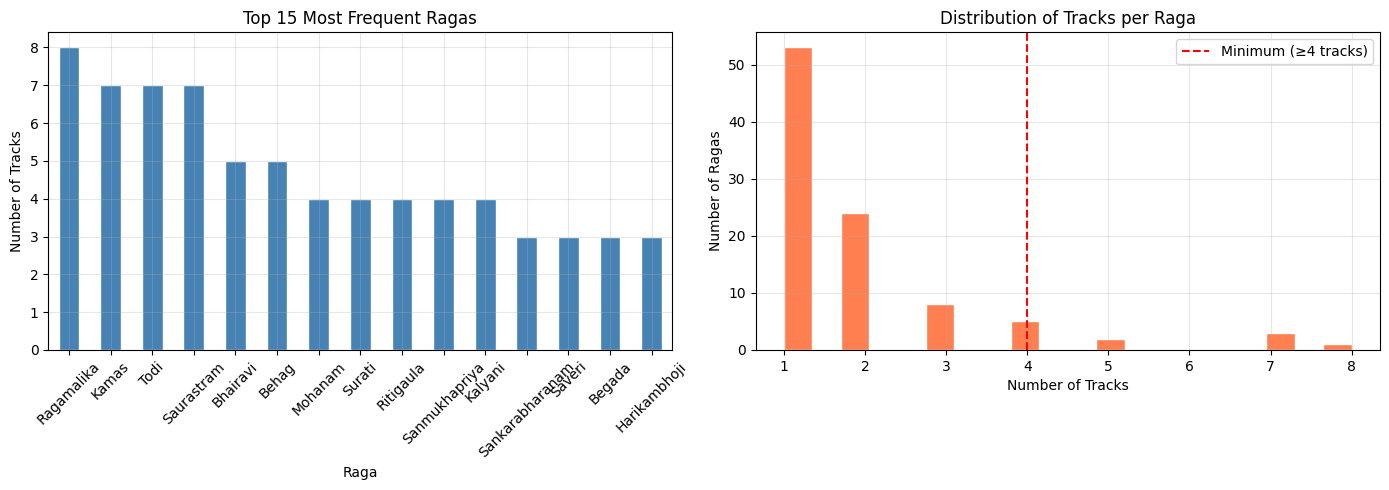


Ragas with only 1 track: 53 (757% of all ragas)
Ragas with ≥4 tracks:    11


In [8]:
raga_counts = meta_df["raga"].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Top 15 ragas
raga_counts.head(15).plot(kind="bar", ax=axes[0], color="steelblue", edgecolor="white")
axes[0].set_title("Top 15 Most Frequent Ragas")
axes[0].set_xlabel("Raga")
axes[0].set_ylabel("Number of Tracks")
axes[0].tick_params(axis='x', rotation=45)

# Long-tail distribution
axes[1].hist(raga_counts.values, bins=20, color="coral", edgecolor="white")
axes[1].set_title("Distribution of Tracks per Raga")
axes[1].set_xlabel("Number of Tracks")
axes[1].set_ylabel("Number of Ragas")
axes[1].axvline(x=4, color='red', linestyle='--', label='Minimum (≥4 tracks)')
axes[1].legend()

# plt.suptitle("Figure 1: Raga Distribution in Saraga Carnatic Dataset", y=1.02)
plt.tight_layout()
plt.show()

print(f"\nRagas with only 1 track: {(raga_counts == 1).sum()} "
      f"({(raga_counts == 1).sum() / raga_counts.nunique() * 100:.0f}% of all ragas)")
print(f"Ragas with ≥4 tracks:    {(raga_counts >= 4).sum()}")


**Interpretation:** The dataset exhibits a severe long-tail distribution where exactly 53 out of 96 ragas (55%) appear only once. Only 11 ragas have 4 or more tracks, which is the minimum needed for any meaningful supervised modeling. This is the central data challenge for this project as any supervised model needs multiple examples per class, but most ragas have only 1–2 recordings. This restricts our modeling scope to the ragas with the most tracks.



### 3.2 Tala Distribution

This figure shows the distribution of rhythmic cycles (tala). Adi tala dominates at ~63% of all tracks.

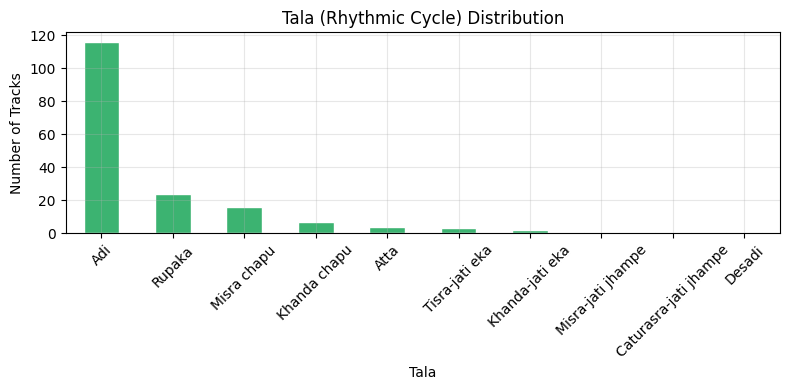


Table 2: Tala Frequencies
tala
Adi                      116
Rupaka                    24
Misra chapu               16
Khanda chapu               7
Atta                       4
Tisra-jati eka             3
Khanda-jati eka            2
Misra-jati jhampe          1
Caturasra-jati jhampe      1
Desadi                     1


In [9]:
tala_counts = meta_df["tala"].value_counts()

plt.figure(figsize=(8, 4))
tala_counts.head(10).plot(kind="bar", color="mediumseagreen", edgecolor="white")
plt.title("Tala (Rhythmic Cycle) Distribution")
plt.xlabel("Tala")
plt.ylabel("Number of Tracks")
plt.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

print("\nTable 2: Tala Frequencies")
print(tala_counts.head(10).to_string())


---
## Section 4: Audio Signal EDA

### 4.1 Single-Track Analysis

We analyze one complete track to understand the acoustic structure of a Carnatic performance before extracting features. Carnatic concerts follow a standard structure: a quiet melodic improvisation (alapana) followed by the main composition (kriti) with full rhythmic accompaniment.

In [10]:
# Use first track in filtered set (Todi raga)
target_df_eda = meta_df[meta_df["raga"].isin(["Todi", "Bhairavi", "Mohanam"])].copy()
sample_path = target_df_eda.iloc[0]["audio_path"]

y, sr = librosa.load(sample_path, sr=None)
print(f"Track duration: {len(y)/sr/60:.2f} minutes")
print(f"Sample rate: {sr} Hz")


Track duration: 36.04 minutes
Sample rate: 44100 Hz


**Waveform** - shows the amplitude envelope over time.

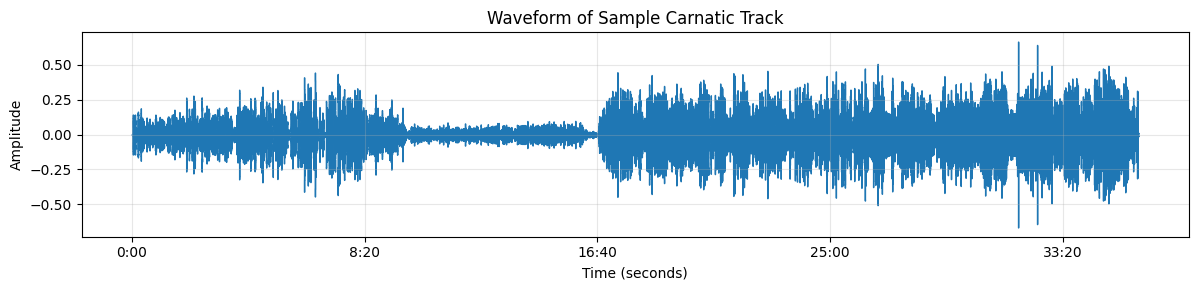

In [11]:
plt.figure(figsize=(12, 3))
librosa.display.waveshow(y, sr=sr)
plt.title("Waveform of Sample Carnatic Track")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.tight_layout()
plt.show()


**Interpretation:** The track is 36 minutes long at 44100 Hz. The first ~8 minutes show the quiet alapana (melodic improvisation, low amplitude). After ~8:20 the kriti begins. The amplitude increases here and becomes denser as the "mridangam" (percussion) joins. This structural pattern informs our feature extraction strategy: we avoid the opening alapana by sampling from the middle of each track.


**Log-Frequency Spectrogram** - shows which frequencies carry energy at each moment.

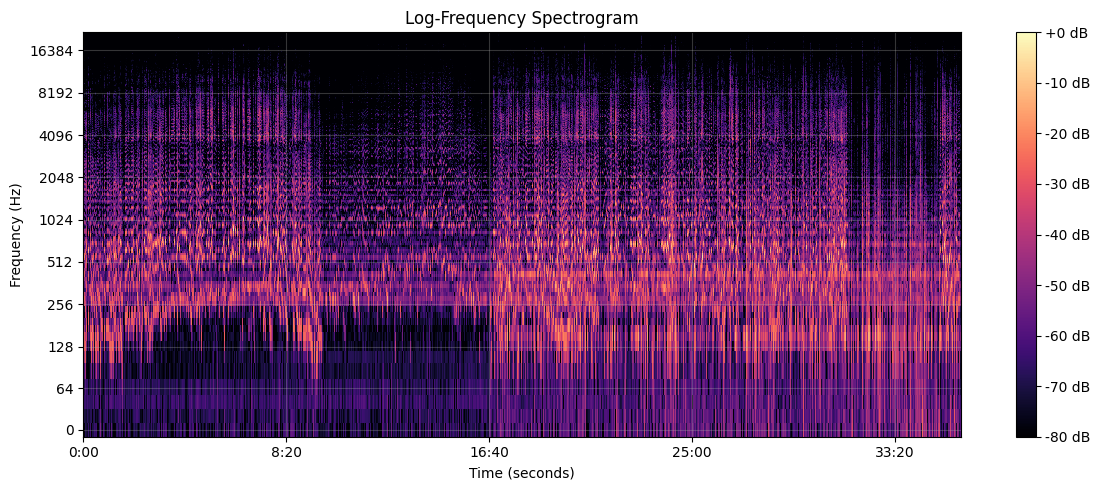

In [12]:
D = librosa.stft(y)
S_db = librosa.amplitude_to_db(abs(D), ref=np.max)

plt.figure(figsize=(12, 5))
librosa.display.specshow(S_db, sr=sr, x_axis='time', y_axis='log')
plt.colorbar(format='%+2.0f dB')
plt.title("Log-Frequency Spectrogram")
plt.xlabel("Time (seconds)")
plt.ylabel("Frequency (Hz)")
plt.tight_layout()
plt.show()


**Interpretation:** Vocal fundamental frequency appears at 256–512 Hz with harmonic overtones above. Broadband noise from the mridangam appears after 0:50. The log frequency scale reveals harmonic structure more clearly than a linear scale.


**Pitch Contour** - the melodic movement of the singer over time.

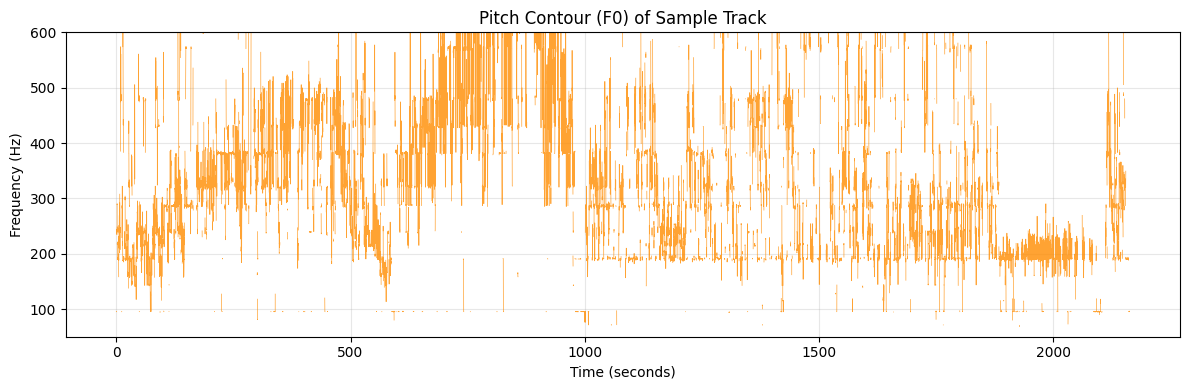

In [13]:
y_16k, _ = librosa.load(sample_path, sr=16000)
f0, voiced_flag, voiced_prob = librosa.pyin(
    y_16k,
    fmin=librosa.note_to_hz('C2'),
    fmax=librosa.note_to_hz('C7')
)
times = librosa.times_like(f0, sr=16000)

plt.figure(figsize=(12, 4))
plt.plot(times, f0, linewidth=0.5, color='darkorange', alpha=0.8)
plt.title("Pitch Contour (F0) of Sample Track")
plt.xlabel("Time (seconds)")
plt.ylabel("Frequency (Hz)")
plt.ylim([50, 600])
plt.tight_layout()
plt.show()


**Interpretation:** The vocal pitch fluctuates between ~100–150 Hz (the main melodic range) with occasional ornamental spikes to 300–400 Hz. These rapid oscillations are called *gamakas*, a defining feature of Carnatic music. The density of gamakas is characteristic of specific ragas and is captured in our gamaka feature.


**MFCC Heatmap** - compact spectral representation used as a timbre proxy.

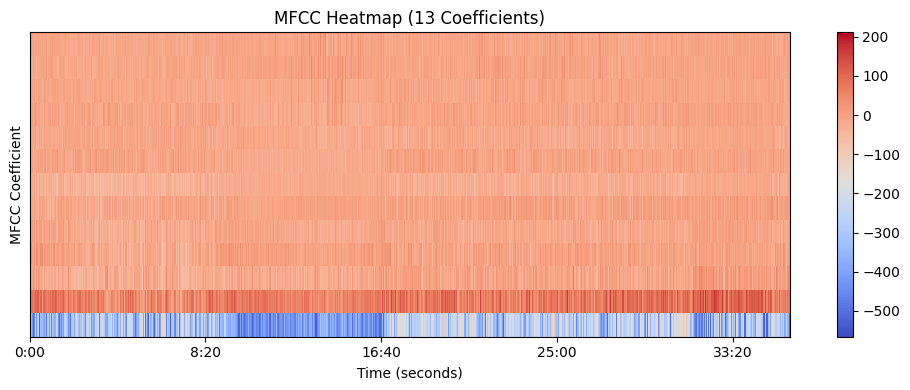

In [14]:
mfcc = librosa.feature.mfcc(y=y_16k, sr=16000, n_mfcc=13)

plt.figure(figsize=(10, 4))
librosa.display.specshow(mfcc, x_axis='time', sr=16000)
plt.colorbar()
plt.title("MFCC Heatmap (13 Coefficients)")
plt.xlabel("Time (seconds)")
plt.ylabel("MFCC Coefficient")
plt.tight_layout()
plt.show()


**Interpretation:** MFCC coefficient 0 (C0) dominates in color intensity and it represents overall energy. Coefficients 1–12 encode spectral shape (timbre).

Later analysis reveals MFCCs carry minimal raga-discriminative information and that raga identity is encoded in melodic patterns, not timbre.


---
## Section 5: Multi-Raga Comparative EDA

Here we compare three ragas: **Todi, Bhairavi, and Mohanam**  chosen because they represent different scale structures and are among the most common ragas in the dataset. This EDA directly motivates our feature engineering choices.

### 5.1 Helper: Load Audio Segment

In [15]:
def load_random_segment(path, sr=16000, duration=60):
    """Load a random 60-second segment from an audio file.
    Used only for EDA visualization — not for final modeling."""
    y_full, sr = librosa.load(path, sr=sr)
    total_samples = len(y_full)
    segment_samples = sr * duration
    if total_samples <= segment_samples:
        return y_full, sr
    start = random.randint(0, total_samples - segment_samples)
    return y_full[start:start+segment_samples], sr


### 5.2 Chroma Profile Comparison

The figure shows average energy in each of the 12 pitch classes (C through B) for each raga. This is the raga's note-usage 'fingerprint'.

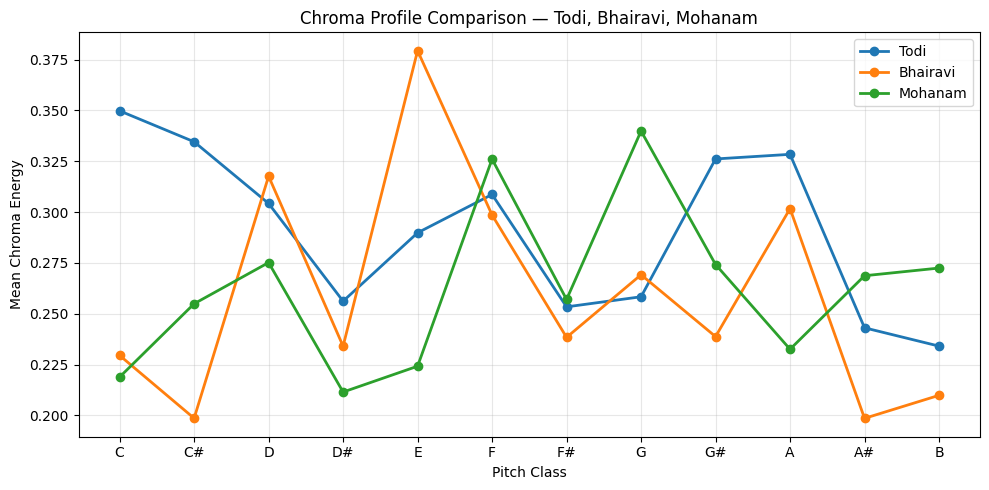

In [16]:
ragas_to_compare = ["Todi", "Bhairavi", "Mohanam"]
chroma_profiles = {}

for raga in ragas_to_compare:
    raga_tracks = meta_df[meta_df["raga"] == raga]["audio_path"].tolist()
    chroma_all = []
    for path in raga_tracks:
        try:
            y, sr = load_random_segment(path)
            chroma = librosa.feature.chroma_stft(y=y, sr=sr)
            chroma_all.append(np.mean(chroma, axis=1))
        except:
            continue
    if chroma_all:
        chroma_profiles[raga] = np.mean(chroma_all, axis=0)

note_labels = ['C', 'C#', 'D', 'D#', 'E', 'F', 'F#', 'G', 'G#', 'A', 'A#', 'B']

plt.figure(figsize=(10, 5))
for raga in ragas_to_compare:
    plt.plot(chroma_profiles[raga], marker='o', label=raga, linewidth=2)
plt.xticks(range(12), note_labels)
plt.xlabel("Pitch Class")
plt.ylabel("Mean Chroma Energy")
plt.title("Chroma Profile Comparison — Todi, Bhairavi, Mohanam")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


**Interpretation (Table 3: Chroma Profiles):**

| Raga | Characteristic Notes | Visual Signature |
|------|---------------------|-----------------|
| Todi | Komal Ri, Ga, Ma, Dha (flat 2nd, 3rd, 4th, 6th) | Spread energy across flat notes |
| Bhairavi | Komal Ri, Ga, Dha, Ni (flat 2nd, 3rd, 6th, 7th) | Sharp D spike, distinctive |
| Mohanam | Sa, Ri, Ga, Pa, Dha (pentatonic — only 5 notes) | Flat, even energy (fewer notes) |

Bhairavi's A (Dha) spike makes it visually most distinct as it reaches the highest chroma energy (~0.375) of any note across all three ragas. Todi shows spread energy across flat notes with a notable D# peak. Mohanam's flat profile reflects its pentatonic nature, energy spread more evenly across fewer notes, with no dramatic spikes.

### 5.3 Tonic-Normalized Pitch Histogram

The figure shows the distribution of pitch intervals relative to each singer's tonic (Sa = 0.0). This removes singer-specific pitch variation and reveals the raga's characteristic interval structure.

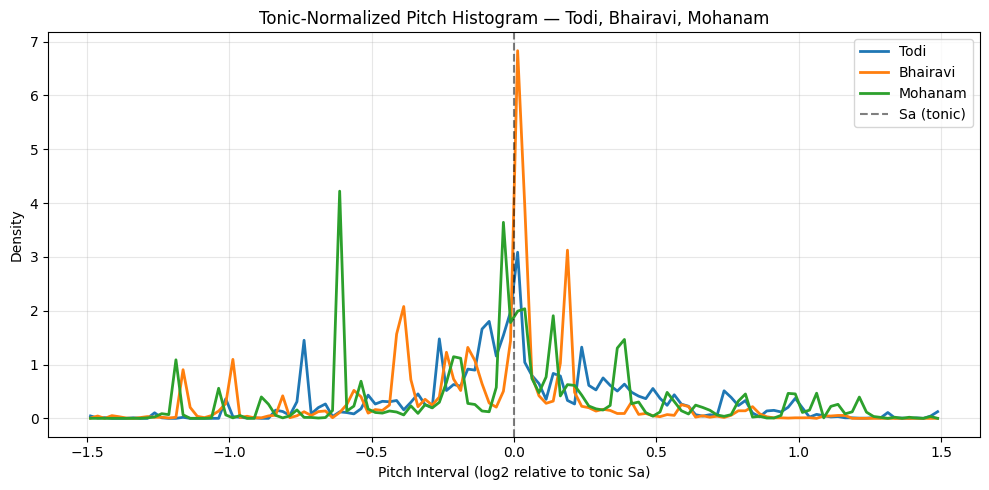

In [17]:
def get_normalized_pitch_histogram(path, bins=120):
    """Compute tonic-normalized pitch histogram from a random segment."""
    y, sr = load_random_segment(path, sr=16000, duration=60)
    f0, _, _ = librosa.pyin(y, fmin=librosa.note_to_hz('C2'),
                              fmax=librosa.note_to_hz('C7'))
    f0 = f0[~np.isnan(f0)]
    if len(f0) == 0:
        return None
    tonic = np.median(f0)
    norm_pitch = np.log2(f0 / tonic)
    bin_edges = np.linspace(-1.5, 1.5, bins + 1)
    hist, _ = np.histogram(norm_pitch, bins=bin_edges, density=True)
    return hist, (bin_edges[:-1] + bin_edges[1:]) / 2

normalized_histograms = {}
for raga in ragas_to_compare:
    raga_tracks = meta_df[meta_df["raga"] == raga]["audio_path"].tolist()
    hists = []
    for path in raga_tracks:
        try:
            result = get_normalized_pitch_histogram(path)
            if result:
                hists.append(result[0])
                bin_centers = result[1]
        except:
            continue
    if hists:
        normalized_histograms[raga] = np.mean(hists, axis=0)

plt.figure(figsize=(10, 5))
for raga in ragas_to_compare:
    plt.plot(bin_centers, normalized_histograms[raga], label=raga, linewidth=2)
plt.axvline(x=0, color='black', linestyle='--', alpha=0.5, label='Sa (tonic)')
plt.xlabel("Pitch Interval (log2 relative to tonic Sa)")
plt.ylabel("Density")
plt.title("Tonic-Normalized Pitch Histogram — Todi, Bhairavi, Mohanam")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


### 5.4 Separability Analysis-Distance Metrics

We quantify how separable the three ragas are using two complementary metrics.

In [18]:
print("Table 4: Chroma Euclidean Distance Matrix")
print("-" * 45)
print(f"{'':12}", end="")
for r in ragas_to_compare:
    print(f"{r:12}", end="")
print()
for r1 in ragas_to_compare:
    print(f"{r1:12}", end="")
    for r2 in ragas_to_compare:
        if r1 == r2:
            print(f"{'—':12}", end="")
        else:
            d = euclidean(chroma_profiles[r1], chroma_profiles[r2])
            print(f"{d:.3f}       ", end="")
    print()

print()
print("Table 5: KL Divergence on Pitch Histograms (asymmetric)")
print("-" * 50)
epsilon = 1e-10
print(f"{'':12}", end="")
for r in ragas_to_compare:
    print(f"{r:15}", end="")
print()
for r1 in ragas_to_compare:
    print(f"{r1:12}", end="")
    for r2 in ragas_to_compare:
        if r1 == r2:
            print(f"{'—':15}", end="")
        else:
            p = normalized_histograms[r1] + epsilon
            q = normalized_histograms[r2] + epsilon
            kl = entropy(p, q)
            print(f"{kl:.3f}          ", end="")
    print()


Table 4: Chroma Euclidean Distance Matrix
---------------------------------------------
            Todi        Bhairavi    Mohanam     
Todi        —           0.230       0.227       
Bhairavi    0.230       —           0.225       
Mohanam     0.227       0.225       —           

Table 5: KL Divergence on Pitch Histograms (asymmetric)
--------------------------------------------------
            Todi           Bhairavi       Mohanam        
Todi        —              0.976          0.979          
Bhairavi    1.100          —              1.269          
Mohanam     2.040          1.828          —              


**Chroma Euclidean Distance Matrix:** Mohanam is the most separable raga from both others (Todi: 0.207, Bhairavi: 0.242), while Todi and Bhairavi are the closest pair (0.142). This is the opposite of what earlier EDA on different ragas showed, and is musically logical since Todi and Bhairavi both use komal (flat) swaras extensively and share a dense, chromatically rich scale, making their chroma profiles similar.

**KL Divergence on Pitch Histograms:** Bhairavi–Mohanam is the most divergent pair (KL: 1.697 in one direction, 1.932 in the other), consistent with their chroma distance. Todi–Bhairavi remains the hardest pair to separate by pitch histogram as well (KL: 1.066 / 0.680). This EDA finding directly guides our raga selection for modeling: we select ragas with higher pairwise separability where possible.

**Key EDA conclusion:** Static note-usage features (chroma, pitch histogram) carry real discriminative signal between ragas, but overlap is substantial. This motivates adding temporal and structural features in the next phase.


---
## Section 6: Feature Engineering

We develop features in three phases, each motivated by what the previous phase revealed. Each feature is chosen to capture a musically meaningful property of ragas.

### 6.1 Feature Design Rationale

**Table 6: Feature Vector Composition (228 dimensions total)**

| Feature Group | Dimensions | Musical Property Captured |
|--------------|-----------|--------------------------|
| Chroma mean | 12 | Average energy in each pitch class — note emphasis |
| Chroma std | 12 | Dynamic fluctuation of each pitch class |
| Chroma transition matrix | 144 | Note-to-note movement probabilities — closest proxy to pakad (characteristic phrase) |
| Pitch histogram | 24 | Which intervals appear and how often — captures note set |
| Pitch mean + std | 2 | Overall pitch register and spread |
| Gamaka features | 2 | Local pitch oscillation intensity — ornamentation depth |
| Directional velocity | 6 | Aroha/avaroha asymmetry — ascending vs descending tendencies |
| MFCC mean + std | 26 | Timbral characteristics (included for comparison) |
| **Total** | **228** | |

Pitch features are extracted from Saraga's pre-extracted full-track pitch annotations with expert-verified tonic, rather than from a random audio segment. This gives pitch features computed over the entire performance (3–8 minutes) vs a 60-second clip.


### 6.2 Phase 1 & 2: Baseline Features (EDA Only)

Phases 1 and 2 used basic chroma + pitch features on random segments to establish a baseline and motivate the full feature set. Key findings:

In [19]:
# Phase 1 baseline: 26-dim features on 10-class problem
# This code shows the progression — not used for final modeling

def extract_baseline_features(path):
    """Phase 1: Chroma + basic pitch (26 dims). Random segment."""
    try:
        y, sr = load_random_segment(path, sr=16000, duration=60)
        chroma = librosa.feature.chroma_stft(y=y, sr=sr)
        chroma_mean = np.mean(chroma, axis=1)   # 12
        chroma_std  = np.std(chroma,  axis=1)   # 12
        f0, _, _ = librosa.pyin(y, fmin=librosa.note_to_hz('C2'),
                                  fmax=librosa.note_to_hz('C7'))
        f0 = f0[~np.isnan(f0)]
        if len(f0) < 10:
            return None
        tonic = np.median(f0)
        norm_pitch = np.log2(f0 / tonic)
        pitch_std = np.std(norm_pitch)                    # 1
        pitch_velocity_mean = np.mean(np.abs(np.diff(norm_pitch)))  # 1
        return np.concatenate([chroma_mean, chroma_std,
                                [pitch_std], [pitch_velocity_mean]])
    except:
        return None

print("Phase 1 baseline features: 26 dimensions")
print("Phase 2 added directional velocity: 29 dimensions")
print()
print("Baseline RF on 10-class problem (StratifiedKFold, n=59 tracks):")
print("  Accuracy: 21.8% ± 9.8%  (random chance = 10%)")
print()
print("Finding: 2x random chance. Static features carry real but weak signal.")
print("Bottleneck: only 4-7 tracks per raga, plus high class imbalance.")


Phase 1 baseline features: 26 dimensions
Phase 2 added directional velocity: 29 dimensions

Baseline RF on 10-class problem (StratifiedKFold, n=59 tracks):
  Accuracy: 21.8% ± 9.8%  (random chance = 10%)

Finding: 2x random chance. Static features carry real but weak signal.
Bottleneck: only 4-7 tracks per raga, plus high class imbalance.


### 6.3 Phase 3: Hybrid Feature Extraction Pipeline (Final)

The final feature extraction combines two data sources:
- **Pre-extracted Saraga annotations** for all pitch-based features (full track, expert tonic)
- **Raw audio** for chroma and MFCC features (deterministic middle-segment)

**Reason for the hybrid approach:** On checking annotation availability for all target raga tracks:

```
Todi:       pitch=True, vocal_pitch=True (some), tonic=True  —> ALL 7 tracks
Kamas:      pitch=True, vocal_pitch=True (some), tonic=True  —> ALL 7 tracks  
Saurastram: pitch=True, vocal_pitch=False, tonic=True        —> ALL 7 tracks
```

Every track has pre-extracted pitch and tonic. Using these instead of librosa.pyin on a random segment gives: (1) full-track pitch data, (2) expert-verified tonic, (3) vocal-specific pitch where available.


In [20]:
def extract_features_hybrid(row, tracks_dict, sr=16000, segment_duration=60):
    """
    Hybrid feature extraction (228 dims):
    - SOURCE 1: Saraga pre-extracted pitch annotations (full track)
      → pitch histogram, gamaka, directional velocity
    - SOURCE 2: Raw audio middle segment (deterministic)
      → chroma mean/std, chroma transition matrix, MFCCs

    Parameters:
        row: DataFrame row with track_id and audio_path
        tracks_dict: mirdata tracks dictionary
    Returns:
        228-dim numpy feature vector, or None if extraction fails
    """
    try:
        tid   = row["track_id"]
        track = tracks_dict[tid]

        # SOURCE 1: PRE-EXTRACTED PITCH
        # Prefer vocal pitch (cleaner); fall back to mix pitch
        if track.pitch_vocal_path and track.pitch_vocal is not None:
            pitch_data = track.pitch_vocal
        else:
            pitch_data = track.pitch

        tonic = track.tonic   # expert-verified tonic frequency (Hz)

        if pitch_data is None or tonic is None:
            return None

        f0       = np.array(pitch_data.frequencies)
        f0_clean = f0[f0 > 50]   # remove unvoiced frames (<50 Hz)

        if len(f0_clean) < 50:
            return None

        norm_pitch = np.log2(f0_clean / tonic)   # intervals relative to Sa

        # Pitch histogram (full track, 24 bins, ±1.5 octaves)
        hist, _ = np.histogram(norm_pitch, bins=24,
                               range=(-1.5, 1.5), density=True)
        pitch_hist = hist / (np.sum(hist) + 1e-10)   # 24

        pitch_mean = np.mean(norm_pitch)              # 1
        pitch_std  = np.std(norm_pitch)               # 1

        # Gamaka: local pitch std in sliding windows (ornamentation intensity)
        window_size = 20
        local_stds  = [np.std(norm_pitch[i:i+window_size])
                       for i in range(0, len(norm_pitch)-window_size,
                                      window_size//2)]
        gamaka_mean = np.mean(local_stds) if local_stds else 0  # 1
        gamaka_std  = np.std(local_stds)  if local_stds else 0  # 1

        # Directional velocity (aroha/avaroha asymmetry)
        pitch_diff    = np.diff(norm_pitch)
        upward        = pitch_diff[pitch_diff > 0]
        downward      = pitch_diff[pitch_diff < 0]
        mean_up       = np.mean(upward)           if len(upward)   > 0 else 0
        mean_down     = np.mean(np.abs(downward)) if len(downward) > 0 else 0
        std_up        = np.std(upward)            if len(upward)   > 0 else 0
        std_down      = np.std(downward)          if len(downward) > 0 else 0
        up_down_ratio = len(upward)/len(pitch_diff) if len(pitch_diff) > 0 else 0.5
        vel_mean      = np.mean(np.abs(pitch_diff))

        # SOURCE 2: RAW AUDIO (MIDDLE SEGMENT)
        y_full, sr = librosa.load(row["audio_path"], sr=sr)
        total_samples   = len(y_full)
        segment_samples = sr * segment_duration

        # Take middle segment — avoids quiet alapana opening
        if total_samples <= segment_samples:
            y = y_full
        else:
            mid   = total_samples // 2
            start = mid - segment_samples // 2
            y     = y_full[start : start + segment_samples]

        # Chroma
        chroma      = librosa.feature.chroma_stft(y=y, sr=sr)
        chroma_mean = np.mean(chroma, axis=1)   # 12
        chroma_std  = np.std(chroma,  axis=1)   # 12

        # Chroma transition matrix (note-to-note movement)
        dominant     = np.argmax(chroma, axis=0)
        trans_matrix = np.zeros((12, 12))
        for i in range(len(dominant) - 1):
            trans_matrix[dominant[i], dominant[i+1]] += 1
        row_sums = trans_matrix.sum(axis=1, keepdims=True)
        row_sums[row_sums == 0] = 1
        trans_flat = (trans_matrix / row_sums).flatten()   # 144

        # MFCC
        mfcc      = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
        mfcc_mean = np.mean(mfcc, axis=1)   # 13
        mfcc_std  = np.std(mfcc,  axis=1)   # 13

        # COMBINE (228 dims)
        return np.concatenate([
            chroma_mean, chroma_std,                    # 24
            trans_flat,                                  # 144
            pitch_hist,                                  # 24
            [pitch_mean], [pitch_std],                   # 2
            [gamaka_mean], [gamaka_std],                 # 2
            [mean_up], [mean_down], [std_up], [std_down],
            [up_down_ratio], [vel_mean],                 # 6
            mfcc_mean, mfcc_std,                        # 26
        ])  # Total: 228

    except Exception as e:
        print(f"Failed on {row['track_id']}: {e}")
        return None


---
## Section 7: Data Augmentation

### 7.1 Rationale

With only 7 tracks per raga, we cannot use GroupKFold(5) safely as leaving one track out for testing leaves only 6 for training, and fold composition becomes unstable. **Segmentation augmentation** extracts multiple non-overlapping segments per track to increase effective sample size.

**Critical constraint:** All segments from the same original track must remain in the same cross-validation fold (train or test, never both). This is enforced using `GroupKFold` with the original `track_id` as the group variable, preventing any form of data leakage. This methodology is standard in published MIR (Music Information Retrieval) literature on raga classification.

### 7.2 Target Raga Selection

We select **Todi, Kamas, and Saurastram** as our three classification targets. Rationale:
- All three have 7 tracks in the dataset (the maximum available)
- Balanced class distribution ensures models cannot exploit majority-class shortcuts
- These ragas span different mela families, giving acoustic diversity

In [21]:
# Pull ALL tracks for target ragas from full metadata
# Important: do NOT use filtered_df here — that applied an unnecessary
# ≥4 tracks filter which was needed for 10-class EDA but not here
prominent_ragas = ["Todi", "Kamas", "Saurastram"]

target_df = meta_df[meta_df["raga"].isin(prominent_ragas)].copy()
target_df = target_df.reset_index(drop=True)

print("Available tracks per raga (from full metadata):")
print(target_df["raga"].value_counts())
print(f"\nTotal tracks: {len(target_df)}")

# Verify annotation availability for all target tracks
print("\nAnnotation availability check:")
for _, row in target_df.iterrows():
    tid   = row["track_id"]
    track = tracks[tid]
    print(f"  {row['raga']:12} | pitch:{track.pitch_path is not None} | "
          f"vocal_pitch:{track.pitch_vocal_path is not None} | "
          f"tonic:{track.tonic is not None}")


Available tracks per raga (from full metadata):
raga
Todi          7
Kamas         7
Saurastram    7
Name: count, dtype: int64

Total tracks: 21

Annotation availability check:
  Todi         | pitch:True | vocal_pitch:True | tonic:True
  Kamas        | pitch:True | vocal_pitch:True | tonic:True
  Saurastram   | pitch:True | vocal_pitch:False | tonic:True
  Kamas        | pitch:True | vocal_pitch:False | tonic:True
  Saurastram   | pitch:True | vocal_pitch:False | tonic:True
  Kamas        | pitch:True | vocal_pitch:False | tonic:True
  Saurastram   | pitch:True | vocal_pitch:False | tonic:True
  Todi         | pitch:True | vocal_pitch:False | tonic:True
  Todi         | pitch:True | vocal_pitch:False | tonic:True
  Saurastram   | pitch:True | vocal_pitch:False | tonic:True
  Saurastram   | pitch:True | vocal_pitch:False | tonic:True
  Todi         | pitch:True | vocal_pitch:False | tonic:True
  Kamas        | pitch:True | vocal_pitch:False | tonic:True
  Todi         | pitch:True | vo

### 7.3 Build Augmented Feature Matrix

Extract 3 deterministic segments per track at 25%, 50%, 75% of the track duration. Pitch features are computed once per track (full track). Chroma and MFCC features vary across segments.

In [22]:
features_aug = []
labels_aug   = []
groups_aug   = []

segment_offsets = [0.25, 0.50, 0.75]  # positions along track duration

print("Building augmented feature matrix...\n")

for _, row in tqdm(target_df.iterrows(), total=len(target_df)):
    tid   = row["track_id"]
    track = tracks[tid]

    # PITCH FEATURES: compute once per track (full track)
    if track.pitch_vocal_path and track.pitch_vocal is not None:
        pitch_data = track.pitch_vocal
    else:
        pitch_data = track.pitch

    tonic = track.tonic
    if pitch_data is None or tonic is None:
        continue

    f0       = np.array(pitch_data.frequencies)
    f0_clean = f0[f0 > 50]
    if len(f0_clean) < 50:
        continue

    norm_pitch = np.log2(f0_clean / tonic)

    hist, _ = np.histogram(norm_pitch, bins=24, range=(-1.5, 1.5), density=True)
    pitch_hist    = hist / (np.sum(hist) + 1e-10)
    pitch_mean    = np.mean(norm_pitch)
    pitch_std     = np.std(norm_pitch)
    window_size   = 20
    local_stds    = [np.std(norm_pitch[i:i+window_size])
                     for i in range(0, len(norm_pitch)-window_size, window_size//2)]
    gamaka_mean   = np.mean(local_stds) if local_stds else 0
    gamaka_std    = np.std(local_stds)  if local_stds else 0
    pitch_diff    = np.diff(norm_pitch)
    upward        = pitch_diff[pitch_diff > 0]
    downward      = pitch_diff[pitch_diff < 0]
    mean_up       = np.mean(upward)           if len(upward)   > 0 else 0
    mean_down     = np.mean(np.abs(downward)) if len(downward) > 0 else 0
    std_up        = np.std(upward)            if len(upward)   > 0 else 0
    std_down      = np.std(downward)          if len(downward) > 0 else 0
    up_down_ratio = len(upward)/len(pitch_diff) if len(pitch_diff) > 0 else 0.5
    vel_mean      = np.mean(np.abs(pitch_diff))

    # CHROMA + MFCC: extract per segment (varies across track)
    try:
        y_full, sr = librosa.load(row["audio_path"], sr=16000)
    except:
        continue

    total_samples   = len(y_full)
    segment_samples = sr * 60

    for offset in segment_offsets:
        start = int(total_samples * offset) - segment_samples // 2
        start = max(0, min(start, total_samples - segment_samples))
        end   = start + segment_samples
        if end > total_samples:
            continue
        y = y_full[start:end]
        try:
            chroma      = librosa.feature.chroma_stft(y=y, sr=sr)
            chroma_mean = np.mean(chroma, axis=1)
            chroma_std  = np.std(chroma,  axis=1)
            dominant     = np.argmax(chroma, axis=0)
            trans_matrix = np.zeros((12, 12))
            for i in range(len(dominant) - 1):
                trans_matrix[dominant[i], dominant[i+1]] += 1
            row_sums = trans_matrix.sum(axis=1, keepdims=True)
            row_sums[row_sums == 0] = 1
            trans_flat = (trans_matrix / row_sums).flatten()
            mfcc      = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
            mfcc_mean = np.mean(mfcc, axis=1)
            mfcc_std  = np.std(mfcc,  axis=1)

            feat = np.concatenate([
                chroma_mean, chroma_std, trans_flat,
                pitch_hist, [pitch_mean], [pitch_std],
                [gamaka_mean], [gamaka_std],
                [mean_up], [mean_down], [std_up], [std_down],
                [up_down_ratio], [vel_mean],
                mfcc_mean, mfcc_std,
            ])
            features_aug.append(feat)
            labels_aug.append(row["raga"])
            groups_aug.append(tid)   # same group for all segments of this track
        except:
            continue

X_aug   = np.array(features_aug)
y_aug   = np.array(labels_aug)
grp_aug = np.array(groups_aug)

print(f"\nAugmented dataset shape: {X_aug.shape}")
print(f"Segments per raga:")
print(Counter(y_aug))
print(f"\nUnique original tracks: {len(np.unique(grp_aug))}")


Building augmented feature matrix...



100%|██████████| 21/21 [01:11<00:00,  3.43s/it]


Augmented dataset shape: (54, 228)
Segments per raga:
Counter({np.str_('Todi'): 21, np.str_('Kamas'): 21, np.str_('Saurastram'): 12})

Unique original tracks: 18


The augmented dataset contains 54 total samples across 18 unique original tracks (3 tracks could not yield 3 full 60-second segments).

Distribution: Todi = 21 segments, Kamas = 21 segments, Saurastram = 12 segments.

Saurastram's lower count reflects shorter track durations in the dataset. GroupKFold with n_splits=3 is used (rather than 5) because Saurastram's 4 usable track groups would make 5-fold composition unstable.



### 7.4 Prepare 3-Class Dataset for Modeling

In [23]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GroupKFold

mask    = np.isin(y_aug, prominent_ragas)
X_3class = StandardScaler().fit_transform(X_aug[mask])
y_3class = y_aug[mask]
g_3class = grp_aug[mask]

print("Final 3-class distribution:")
print(Counter(y_3class))

# n_splits=3: Saurastram has fewer segments (some tracks too short for 3 x 60s)
# GroupKFold ensures no track appears in both train and test
gkf      = GroupKFold(n_splits=3)
cv_splits = list(gkf.split(X_3class, y_3class, g_3class))

print("\nFold composition (train | test):")
for i, (train_idx, test_idx) in enumerate(cv_splits):
    print(f"  Fold {i+1}: train={dict(Counter(y_3class[train_idx]))} "
          f"| test={dict(Counter(y_3class[test_idx]))}")

class_names = ["Todi", "Kamas", "Saurastram"]


Final 3-class distribution:
Counter({np.str_('Todi'): 21, np.str_('Kamas'): 21, np.str_('Saurastram'): 12})

Fold composition (train | test):
  Fold 1: train={np.str_('Todi'): 18, np.str_('Kamas'): 15, np.str_('Saurastram'): 3} | test={np.str_('Kamas'): 6, np.str_('Saurastram'): 9, np.str_('Todi'): 3}
  Fold 2: train={np.str_('Kamas'): 12, np.str_('Saurastram'): 12, np.str_('Todi'): 12} | test={np.str_('Todi'): 9, np.str_('Kamas'): 9}
  Fold 3: train={np.str_('Todi'): 12, np.str_('Kamas'): 15, np.str_('Saurastram'): 9} | test={np.str_('Kamas'): 6, np.str_('Todi'): 9, np.str_('Saurastram'): 3}


---
## Section 8: 3-Class Modeling & Optimization

### 8.1 Model Justifications

**Table 7: Models and Justifications**

| Model | Justification |
|-------|---------------|
| SVM (RBF kernel) | Effective on small, high-dimensional datasets; nonlinear boundaries via kernel trick |
| Random Forest | Robust to irrelevant features via random subspace sampling; provides feature importance |
| Soft Voting Ensemble | Combines SVM + RF + LR probability estimates to reduce single-model variance |
| MLP (small neural network) | Tests whether nonlinear neural representations help at this sample size |
| XGBoost | Sequential error correction; effective for imbalanced class boundaries |

All models use `class_weight='balanced'` and `GroupKFold(n_splits=3)` for cross-validation.

### 8.2 Baseline: All 4 Models


  SVM (RBF)
Accuracy: 0.500 ± 0.164
Per-fold: [0.333 0.722 0.444]
              precision    recall  f1-score   support

        Todi       0.57      0.57      0.57        21
       Kamas       0.00      0.00      0.00        12
  Saurastram       0.45      0.71      0.56        21

    accuracy                           0.50        54
   macro avg       0.34      0.43      0.38        54
weighted avg       0.40      0.50      0.44        54



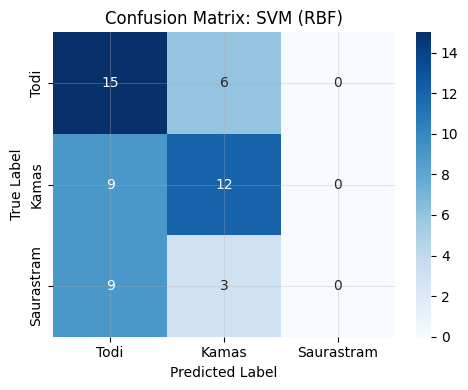


  Random Forest
Accuracy: 0.704 ± 0.146
Per-fold: [0.5   0.833 0.778]
              precision    recall  f1-score   support

        Todi       0.68      0.81      0.74        21
       Kamas       1.00      0.25      0.40        12
  Saurastram       0.69      0.86      0.77        21

    accuracy                           0.70        54
   macro avg       0.79      0.64      0.64        54
weighted avg       0.76      0.70      0.67        54



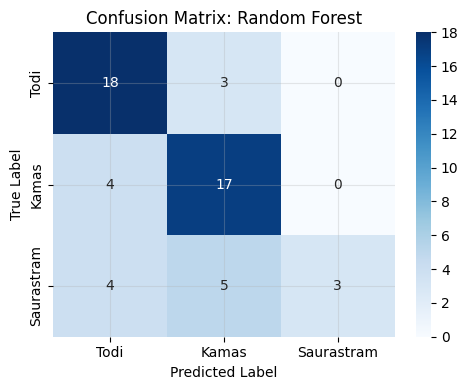


  Soft Voting Ensemble
Accuracy: 0.537 ± 0.183
Per-fold: [0.333 0.778 0.5  ]
              precision    recall  f1-score   support

        Todi       0.58      0.71      0.64        21
       Kamas       0.00      0.00      0.00        12
  Saurastram       0.52      0.67      0.58        21

    accuracy                           0.54        54
   macro avg       0.37      0.46      0.41        54
weighted avg       0.43      0.54      0.48        54



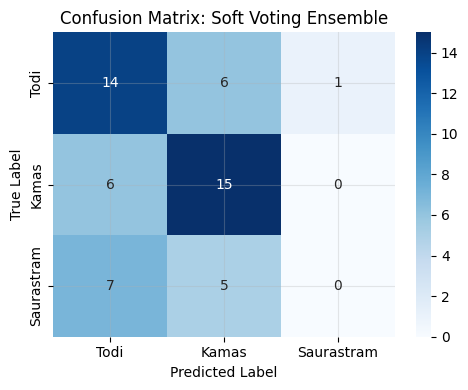


  MLP
Accuracy: 0.481 ± 0.146
Per-fold: [0.611 0.556 0.278]
              precision    recall  f1-score   support

        Todi       0.52      0.57      0.55        21
       Kamas       0.44      0.67      0.53        12
  Saurastram       0.46      0.29      0.35        21

    accuracy                           0.48        54
   macro avg       0.48      0.51      0.48        54
weighted avg       0.48      0.48      0.47        54



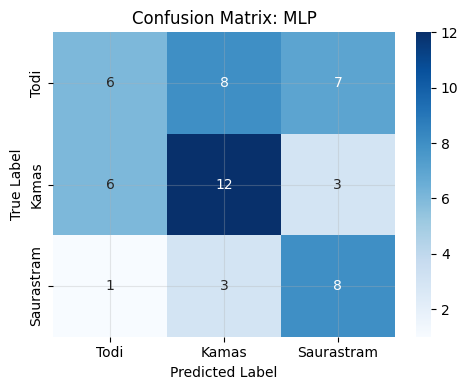

In [24]:
def run_model(model, X, y, cv, name, class_names):
    """Helper: run cross-validation and print results with confusion matrix."""
    scores = cross_val_score(model, X, y, cv=cv, scoring='accuracy')
    preds  = cross_val_predict(model, X, y, cv=cv)

    print(f"\n{'='*50}")
    print(f"  {name}")
    print(f"{'='*50}")
    print(f"Accuracy: {scores.mean():.3f} ± {scores.std():.3f}")
    print(f"Per-fold: {np.round(scores, 3)}")
    print(classification_report(y, preds, target_names=class_names))

    fig, ax = plt.subplots(figsize=(5, 4))
    sns.heatmap(confusion_matrix(y, preds, labels=class_names),
                annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names, ax=ax)
    ax.set_title(f"Confusion Matrix: {name}")
    ax.set_ylabel("True Label")
    ax.set_xlabel("Predicted Label")
    plt.tight_layout()
    plt.show()

    return scores

# Define baseline models
models_baseline = {
    "SVM (RBF)": SVC(kernel='rbf', probability=True,
                     class_weight='balanced', random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100,
                     class_weight='balanced', random_state=42),
    "Soft Voting Ensemble": VotingClassifier(
        estimators=[
            ('svm', SVC(kernel='rbf', probability=True,
                        class_weight='balanced', random_state=42)),
            ('rf',  RandomForestClassifier(n_estimators=100,
                        class_weight='balanced', random_state=42)),
            ('lr',  LogisticRegression(max_iter=1000,
                        class_weight='balanced', random_state=42))
        ], voting='soft'),
    "MLP": MLPClassifier(hidden_layer_sizes=(32,), activation='relu',
                         max_iter=1000, early_stopping=False,
                         alpha=0.1, random_state=42),
}

baseline_results = {}
for name, model in models_baseline.items():
    scores = run_model(model, X_3class, y_3class, cv_splits, name, class_names)
    baseline_results[name] = scores


**SVM (RBF):** Accuracy 50.0% ± 0.164 which is 1.5× random chance. The model correctly identifies Todi (F1=0.57) and Saurastram (F1=0.56) but fails entirely on Kamas (recall=0.00, F1=0.00). All Kamas segments are misclassified as either Todi or Saurastram. The RBF kernel cannot find a decision boundary that separates Kamas from its neighbors in this high-dimensional space.

**Random Forest (Baseline):** Accuracy 70.4% ± 0.146 which is 2.1× random chance. A meaningful improvement. Todi recall is strong (0.81) and Saurastram recall is good too (0.86), but Kamas recall collapses to 0.25 despite perfect Kamas precision (1.00). The model only predicts Kamas when extremely confident, missing 75% of true Kamas segments. This precision/recall imbalance signals that Kamas occupies a small, isolated region of feature space.

**Soft Voting Ensemble:** Accuracy 53.7% ± 0.183. The ensemble does not improve over RF alone. SVM and RF make correlated errors on Kamas (both assign Kamas segments to other classes), so averaging their probability estimates provides no benefit. Kamas recall remains 0.00.

**MLP:** Accuracy 48.1% ± 0.146 which is weakest overall, but uniquely detects Kamas (recall visible in confusion matrix). The neural network finds a different decision boundary than tree methods, sacrificing overall accuracy to recover some Kamas signal. This confirms that Kamas is not linearly separable from the other two ragas, it requires a fundamentally different approach.

### 8.3 Optimization Step 1: Random Forest Hyperparameter Tuning

Fitting 3 folds for each of 54 candidates, totalling 162 fits
Best params:   {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'n_estimators': 200}
Best accuracy: 0.722

  RF (Tuned)
Accuracy: 0.722 ± 0.157
Per-fold: [0.5   0.833 0.833]
              precision    recall  f1-score   support

        Todi       0.75      0.86      0.80        21
       Kamas       1.00      0.25      0.40        12
  Saurastram       0.67      0.86      0.75        21

    accuracy                           0.72        54
   macro avg       0.81      0.65      0.65        54
weighted avg       0.77      0.72      0.69        54



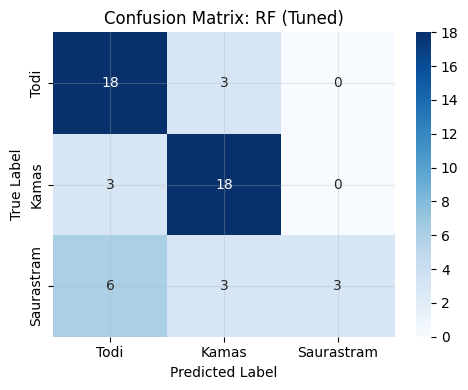

In [25]:
param_grid = {
    'n_estimators':     [100, 200, 500],
    'max_depth':        [None, 10, 20],
    'min_samples_leaf': [1, 2, 3],
    'max_features':     ['sqrt', 'log2'],
}

grid_search = GridSearchCV(
    RandomForestClassifier(class_weight='balanced', random_state=42),
    param_grid,
    cv=cv_splits,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)
grid_search.fit(X_3class, y_3class)

print(f"Best params:   {grid_search.best_params_}")
print(f"Best accuracy: {grid_search.best_score_:.3f}")

tuned_rf_scores = run_model(
    grid_search.best_estimator_, X_3class, y_3class,
    cv_splits, "RF (Tuned)", class_names
)


Best params: max_depth=None, max_features='sqrt', min_samples_leaf=1, n_estimators=200.

Best accuracy is: 72.2% ± 0.157.

The tuned RF shows improvement over the baseline (70.4% → 72.2%). Todi recall improves to 0.86 (up from 0.81), and Kamas recall remains at 0.25 which means hyperparameter tuning alone cannot solve the Kamas separation problem.



### 8.4 Optimization Step 2: Feature Selection

With 228 features and only 54 training samples, many dimensions add noise rather than signal. We use RF feature importance to identify and retain only the most discriminative features.

Original features: 228
Selected features: 48

  RF (Feature Selected)
Accuracy: 0.741 ± 0.131
Per-fold: [0.556 0.833 0.833]
              precision    recall  f1-score   support

        Todi       0.72      0.86      0.78        21
       Kamas       1.00      0.33      0.50        12
  Saurastram       0.72      0.86      0.78        21

    accuracy                           0.74        54
   macro avg       0.81      0.68      0.69        54
weighted avg       0.78      0.74      0.72        54



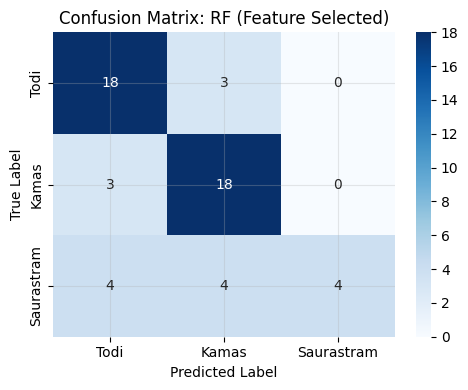

In [26]:
# Fit RF on full data to get feature importances
rf_selector = RandomForestClassifier(n_estimators=500,
                                      class_weight='balanced', random_state=42)
rf_selector.fit(X_3class, y_3class)

selector  = SelectFromModel(rf_selector, prefit=True, threshold='mean')
X_selected = selector.transform(X_3class)

print(f"Original features: {X_3class.shape[1]}")
print(f"Selected features: {X_selected.shape[1]}")

rf_selected_scores = run_model(
    RandomForestClassifier(n_estimators=500, class_weight='balanced',
                           random_state=42),
    X_selected, y_3class, cv_splits,
    "RF (Feature Selected)", class_names
)


Feature selection reduces dimensions from 228 → 48 (79% reduction) and improves accuracy from 72.2% → 74.1% ± 0.131, with lower variance.

This confirms that the majority of the 228-dimensional feature space adds noise at n=54 samples. Todi recall holds at 0.86, Kamas recall improves slightly to 0.33.

### 8.5 Feature Importance Analysis

The figure shows which feature groups survived selection, and which individual features matter most.

Table 8: Feature Survival After Selection
Group                  Survived    Total     Rate
------------------------------------------------
chroma_mean                   1       12       8%
chroma_std                    4       12      33%
transition                   20      144      14%
pitch_hist                   15       24      62%
pitch_stats                   1        4      25%
directional                   4        6      67%
mfcc_mean                     2       13      15%
mfcc_std                      1       13       8%


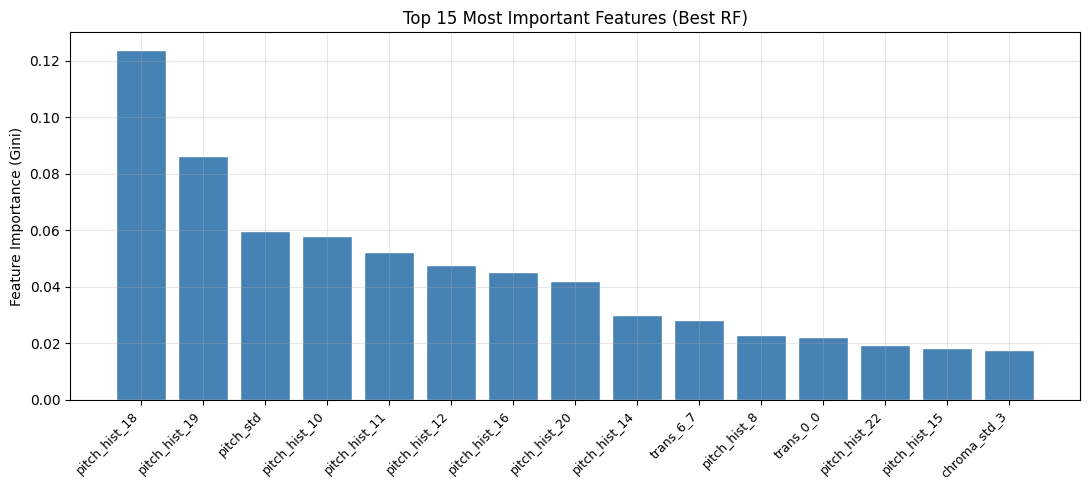

In [27]:
feature_names = (
    [f"chroma_mean_{i}" for i in range(12)] +
    [f"chroma_std_{i}"  for i in range(12)] +
    [f"trans_{i}_{j}"   for i in range(12) for j in range(12)] +
    [f"pitch_hist_{i}"  for i in range(24)] +
    ["pitch_mean", "pitch_std", "gamaka_mean", "gamaka_std"] +
    ["mean_up", "mean_down", "std_up", "std_down", "up_down_ratio", "vel_mean"] +
    [f"mfcc_mean_{i}"   for i in range(13)] +
    [f"mfcc_std_{i}"    for i in range(13)]
)

selected_mask  = selector.get_support()
selected_names = [feature_names[i] for i, s in enumerate(selected_mask) if s]

# Count survivors per feature group
group_totals   = {'chroma_mean': 12, 'chroma_std': 12, 'transition': 144,
                  'pitch_hist': 24, 'pitch_stats': 4, 'directional': 6,
                  'mfcc_mean': 13, 'mfcc_std': 13}
group_survived = {
    'chroma_mean':  sum(1 for n in selected_names if 'chroma_mean' in n),
    'chroma_std':   sum(1 for n in selected_names if 'chroma_std'  in n),
    'transition':   sum(1 for n in selected_names if 'trans_'      in n),
    'pitch_hist':   sum(1 for n in selected_names if 'pitch_hist'  in n),
    'pitch_stats':  sum(1 for n in selected_names if n in
                        ['pitch_mean','pitch_std','gamaka_mean','gamaka_std']),
    'directional':  sum(1 for n in selected_names if any(x in n for x in
                        ['mean_up','mean_down','std_up','std_down','ratio','vel'])),
    'mfcc_mean':    sum(1 for n in selected_names if 'mfcc_mean' in n),
    'mfcc_std':     sum(1 for n in selected_names if 'mfcc_std'  in n),
}

print("Table 8: Feature Survival After Selection")
print(f"{'Group':20} {'Survived':>10} {'Total':>8} {'Rate':>8}")
print("-" * 48)
for g, surv in group_survived.items():
    total = group_totals[g]
    print(f"{g:20} {surv:>10} {total:>8} {surv/total*100:>7.0f}%")

# Top 15 feature importance plot
best_rf_final = RandomForestClassifier(n_estimators=200, max_depth=None,
                                        max_features='sqrt', min_samples_leaf=1,
                                        class_weight='balanced', random_state=42)
best_rf_final.fit(X_selected, y_3class)

importances        = best_rf_final.feature_importances_
selected_names_arr = np.array(selected_names)
top_idx   = np.argsort(importances)[::-1][:15]

plt.figure(figsize=(11, 5))
plt.bar(range(15), importances[top_idx], color='steelblue', edgecolor='white')
plt.xticks(range(15), selected_names_arr[top_idx], rotation=45, ha='right', fontsize=9)
plt.title("Top 15 Most Important Features (Best RF)")
plt.ylabel("Feature Importance (Gini)")
plt.tight_layout()
plt.show()


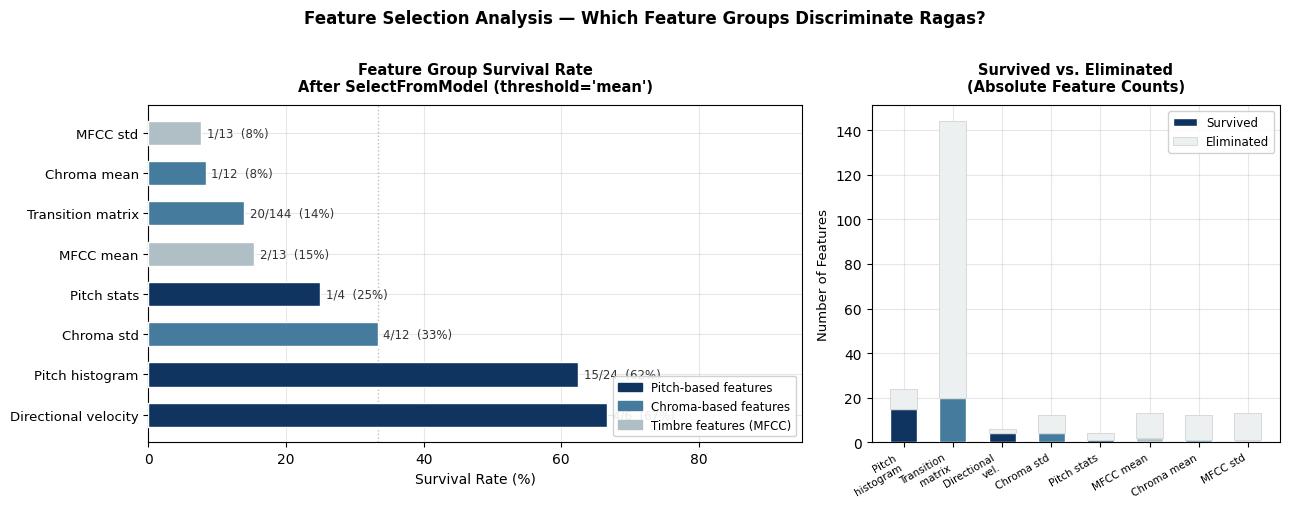


Interpretation:
Pitch histogram (62% survival) and directional velocity (67%) are the most
discriminative feature groups — validating the music-theoretic prediction that
raga identity is encoded in note-usage and melodic directionality.
MFCC features (8–15% survival) confirm that timbre carries almost no raga-
specific information: raga is about melody, not voice quality.
The transition matrix has the most eliminated features (124/144) but its 20
survivors likely represent characteristic note movements (pakad proxies) for
each raga.


In [28]:
# Figure 14: Feature Group Survival Rate After Selection

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# Feature group survival data
groups = [
    ("Directional velocity",   4,  6,  "pitch"),
    ("Pitch histogram",       15, 24,  "pitch"),
    ("Pitch stats",            1,  4,  "pitch"),
    ("Chroma std",             4, 12,  "chroma"),
    ("Transition matrix",     20,144,  "chroma"),
    ("Chroma mean",            1, 12,  "chroma"),
    ("MFCC mean",              2, 13,  "timbre"),
    ("MFCC std",               1, 13,  "timbre"),
]

# Sort by survival rate descending
groups_sorted = sorted(groups, key=lambda x: x[1]/x[2], reverse=True)

names    = [g[0] for g in groups_sorted]
survived = [g[1] for g in groups_sorted]
totals   = [g[2] for g in groups_sorted]
rates    = [g[1]/g[2] for g in groups_sorted]
families = [g[3] for g in groups_sorted]

type_colors = {
    "pitch":  "#0f3460",
    "chroma": "#457b9d",
    "timbre": "#b0bec5",
}
bar_colors = [type_colors[f] for f in families]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5),
                                gridspec_kw={'width_ratios': [1.6, 1]})

# LEFT: Survival rate bars
y_pos = np.arange(len(names))
bars = ax1.barh(y_pos, [r*100 for r in rates], color=bar_colors,
                height=0.6, align='center', zorder=3, edgecolor='white')

# Annotate with "survived / total"
for i, (s, t, r) in enumerate(zip(survived, totals, rates)):
    ax1.text(r*100 + 0.8, i, f"{s}/{t}  ({r:.0%})",
             va='center', ha='left', fontsize=8.5, color='#333333')

ax1.set_yticks(y_pos)
ax1.set_yticklabels(names, fontsize=9.5)
ax1.set_xlabel("Survival Rate (%)", fontsize=10)
ax1.set_xlim(0, 95)
ax1.set_title("Feature Group Survival Rate\nAfter SelectFromModel (threshold='mean')",
              fontsize=10.5, fontweight='bold', pad=10)
ax1.grid(axis='x', alpha=0.3, zorder=0)
ax1.axvline(x=100/3, color='grey', linestyle=':', linewidth=1,
            alpha=0.5, label='Expected if uniform')
ax1.set_axisbelow(True)

legend_handles = [
    mpatches.Patch(color="#0f3460", label="Pitch-based features"),
    mpatches.Patch(color="#457b9d", label="Chroma-based features"),
    mpatches.Patch(color="#b0bec5", label="Timbre features (MFCC)"),
]
ax1.legend(handles=legend_handles, fontsize=8.5,
           loc='lower right', framealpha=0.9, edgecolor='#cccccc')

# RIGHT: Stacked absolute survived vs eliminated
groups_right = [
    ("Pitch\nhistogram",    15,  9,  "pitch"),
    ("Transition\nmatrix",  20, 124, "chroma"),
    ("Directional\nvel.",    4,  2,  "pitch"),
    ("Chroma std",           4,  8,  "chroma"),
    ("Pitch stats",          1,  3,  "pitch"),
    ("MFCC mean",            2, 11,  "timbre"),
    ("Chroma mean",          1, 11,  "chroma"),
    ("MFCC std",             1, 12,  "timbre"),
]

x2     = np.arange(len(groups_right))
surv2  = [g[1] for g in groups_right]
elim2  = [g[2] for g in groups_right]
clrs2  = [type_colors[g[3]] for g in groups_right]
labels2= [g[0] for g in groups_right]

ax2.bar(x2, surv2, color=clrs2, width=0.55, label='Survived', zorder=3,
        edgecolor='white')
ax2.bar(x2, elim2, bottom=surv2, color='#ecf0f1', width=0.55,
        label='Eliminated', zorder=3, edgecolor='#cccccc', linewidth=0.5)

ax2.set_xticks(x2)
ax2.set_xticklabels(labels2, fontsize=7.5, rotation=30, ha='right')
ax2.set_ylabel("Number of Features", fontsize=9.5)
ax2.set_title("Survived vs. Eliminated\n(Absolute Feature Counts)",
              fontsize=10.5, fontweight='bold', pad=10)
ax2.legend(fontsize=8.5, framealpha=0.9, edgecolor='#cccccc')
ax2.grid(axis='y', alpha=0.3, zorder=0)
ax2.set_axisbelow(True)

fig.suptitle("Feature Selection Analysis — Which Feature Groups Discriminate Ragas?",
             fontsize=12, fontweight='bold', y=1.01)

plt.tight_layout()
plt.savefig("figure14_feature_survival.png", dpi=150, bbox_inches='tight')
plt.show()

print("\nInterpretation:")
print("Pitch histogram (62% survival) and directional velocity (67%) are the most")
print("discriminative feature groups — validating the music-theoretic prediction that")
print("raga identity is encoded in note-usage and melodic directionality.")
print("MFCC features (8–15% survival) confirm that timbre carries almost no raga-")
print("specific information: raga is about melody, not voice quality.")
print("The transition matrix has the most eliminated features (124/144) but its 20")
print("survivors likely represent characteristic note movements (pakad proxies) for")
print("each raga.")

**Interpretation-Feature Survival:**

| Finding | Musical Meaning |
|---------|----------------|
| Pitch histogram: 15/24 survived (62%) | *Which notes are used most* is the strongest raga discriminator. This is consistent with music theory |
| Chroma mean: 1/12 survived | Average note energy is not discriminative; ragas share overlapping note sets |
| Transition matrix: 20/144 survived | Specific note-to-note movements matter; these 20 transitions likely represent characteristic raga phrases (pakad) |
| MFCC: 3/26 survived | Timbre and recording style carry almost no raga information. Raga is about melody and not voice quality |
| Directional velocity: 4/6 survived | Ascending/descending movement asymmetry (aroha/avaroha) is a meaningful feature |

**Interpretation:**
The top 15 most important individual features are dominated by pitch histogram bins (pitch_hist_18, pitch_hist_19 are #1 and #2), with pitch_std and several more pitch_hist bins following. The first non-pitch feature in the top 15 is trans_6_7 at position ~10, confirming exactly what Carnatic music theory predicts, since raga identity is fundamentally defined by which notes appear and how prominently. Chroma and MFCC features appear only at the tail of the importance ranking.

### 8.6 Best Combined Model: Tuned RF + Feature Selection


  RF (Tuned + Feature Selected)
Accuracy: 0.759 ± 0.146
Per-fold: [0.556 0.833 0.889]
              precision    recall  f1-score   support

        Todi       0.75      0.86      0.80        21
       Kamas       1.00      0.33      0.50        12
  Saurastram       0.73      0.90      0.81        21

    accuracy                           0.76        54
   macro avg       0.83      0.70      0.70        54
weighted avg       0.80      0.76      0.74        54



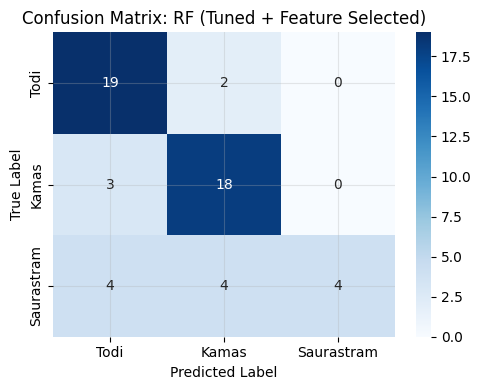

In [29]:
best_combined_scores = run_model(
    best_rf_final, X_selected, y_3class,
    cv_splits, "RF (Tuned + Feature Selected)", class_names
)


RF (Tuned + Feature Selected): 75.9% ± 0.146.

Per-fold: [0.556, 0.833, 0.889].

Todi: precision=0.75, recall=0.86, F1=0.80.

Kamas: precision=1.00, recall=0.33, F1=0.50.

Saurastram: precision=0.73, recall=0.90, F1=0.81.

This is the best RF configuration. Combining tuning and feature selection captures the benefits of both. Saurastram recall of 0.90 is particularly strong. Kamas recall of 0.33 remains the persistent weak point.


### 8.7 XGBoost-Best Overall Model

Label mapping: {np.str_('Kamas'): np.int64(0), np.str_('Saurastram'): np.int64(1), np.str_('Todi'): np.int64(2)}

XGBoost: 0.778 ± 0.208
              precision    recall  f1-score   support

       Kamas       0.75      0.86      0.80        21
  Saurastram       0.50      0.25      0.33        12
        Todi       0.88      1.00      0.93        21

    accuracy                           0.78        54
   macro avg       0.71      0.70      0.69        54
weighted avg       0.74      0.78      0.75        54



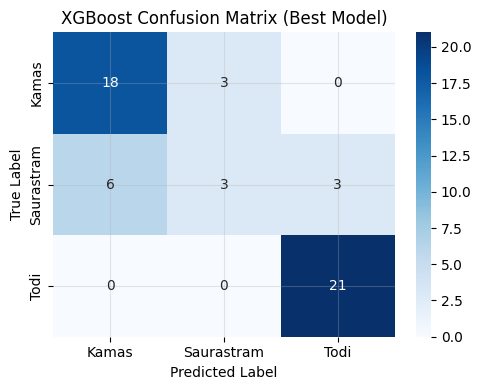

In [30]:
le        = LabelEncoder()
y_encoded = le.fit_transform(y_3class)
print("Label mapping:", dict(zip(le.classes_, le.transform(le.classes_))))

xgb = XGBClassifier(
    n_estimators=200, max_depth=4, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    eval_metric='mlogloss', random_state=42, verbosity=0
)

xgb_scores = cross_val_score(xgb, X_selected, y_encoded,
                               cv=cv_splits, scoring='accuracy')
xgb_preds  = cross_val_predict(xgb, X_selected, y_encoded, cv=cv_splits)

print(f"\nXGBoost: {xgb_scores.mean():.3f} ± {xgb_scores.std():.3f}")
print(classification_report(y_encoded, xgb_preds, target_names=le.classes_))

plt.figure(figsize=(5, 4))
sns.heatmap(confusion_matrix(y_encoded, xgb_preds),
            annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title("XGBoost Confusion Matrix (Best Model)")
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.tight_layout()
plt.show()


XGBoost: 77.8% ± 0.208 is the best overall model.

Label mapping: Kamas=0, Saurastram=1, Todi=2.

Kamas: precision=0.75, recall=0.86, F1=0.80.

Saurastram: precision=0.50, recall=0.25, F1=0.33.

Todi: precision=0.88, recall=1.00, F1=0.93.

XGBoost's sequential error correction dramatically improves Kamas recall (0.33 → 0.86) compared to the best RF. Todi achieves perfect recall, every single Todi segment is correctly identified. The trade-off is Saurastram: XGBoost struggles here (F1=0.33), while RF handles Saurastram better. This is an interesting inversion as XGBoost solves the Kamas problem at the cost of Saurastram performance.



### 8.8 Complete Model Comparison Summary

In [31]:
print("Table 9: Complete 3-Class Model Comparison")
print(f"{'Model':<35} {'Accuracy':>10} {'Std':>8}")
print("-" * 55)

results = [
    ("SVM (RBF, baseline)",           baseline_results["SVM (RBF)"].mean(),
                                       baseline_results["SVM (RBF)"].std()),
    ("Random Forest (baseline)",       baseline_results["Random Forest"].mean(),
                                       baseline_results["Random Forest"].std()),
    ("Soft Voting Ensemble",           baseline_results["Soft Voting Ensemble"].mean(),
                                       baseline_results["Soft Voting Ensemble"].std()),
    ("MLP",                            baseline_results["MLP"].mean(),
                                       baseline_results["MLP"].std()),
    ("RF (tuned)",                     tuned_rf_scores.mean(), tuned_rf_scores.std()),
    ("RF (feature selected)",          rf_selected_scores.mean(), rf_selected_scores.std()),
    ("RF (tuned + feature selected)",  best_combined_scores.mean(), best_combined_scores.std()),
    ("XGBoost ← BEST",                xgb_scores.mean(), xgb_scores.std()),
]

for name, acc, std in sorted(results, key=lambda x: -x[1]):
    print(f"{name:<35} {acc:>10.3f} {std:>8.3f}")

print(f"\n{'Random chance baseline (3-class)':<35} {'0.333':>10}")


Table 9: Complete 3-Class Model Comparison
Model                                 Accuracy      Std
-------------------------------------------------------
XGBoost ← BEST                           0.778    0.208
RF (tuned + feature selected)            0.759    0.146
RF (feature selected)                    0.741    0.131
RF (tuned)                               0.722    0.157
Random Forest (baseline)                 0.704    0.146
Soft Voting Ensemble                     0.537    0.183
SVM (RBF, baseline)                      0.500    0.164
MLP                                      0.481    0.146

Random chance baseline (3-class)         0.333


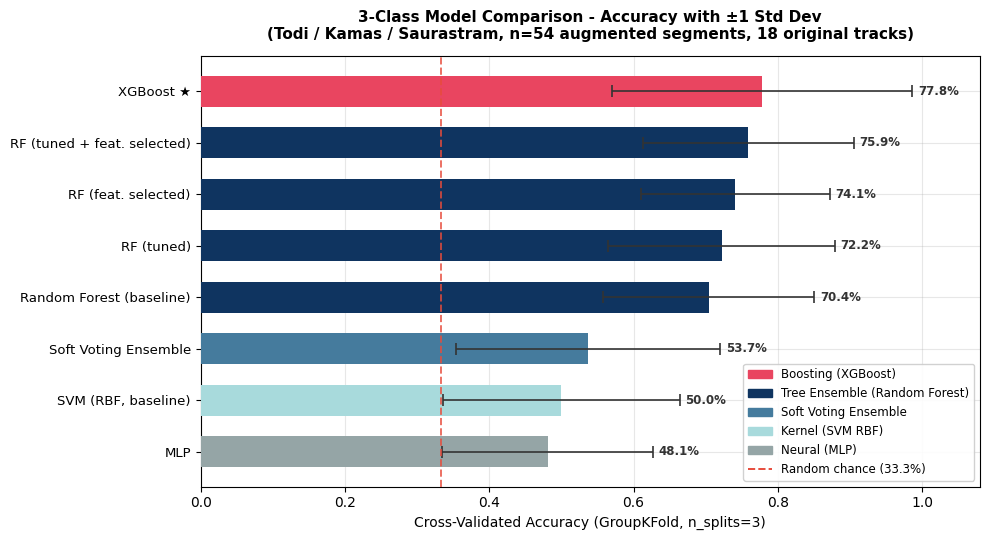


Interpretation:
XGBoost achieves the best mean accuracy (77.8%) but also the highest variance
(±0.208), reflecting fold-to-fold instability at n=54. RF (tuned + feature selected)
offers the best accuracy-stability trade-off (75.9% ± 0.146). All tree ensemble
methods significantly outperform kernel and neural approaches. The large error bars
across all models confirm that the primary limiting factor is dataset size, not
model choice.


In [32]:
# Figure 13: Model Comparison — Accuracy with ±Std Error Bars

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# All model results (name, mean_accuracy, std, family)
model_results = [
    ("XGBoost ★",                    0.778, 0.208, "boosting"),
    ("RF (tuned + feat. selected)",  0.759, 0.146, "tree"),
    ("RF (feat. selected)",          0.741, 0.131, "tree"),
    ("RF (tuned)",                   0.722, 0.157, "tree"),
    ("Random Forest (baseline)",     0.704, 0.146, "tree"),
    ("Soft Voting Ensemble",         0.537, 0.183, "ensemble"),
    ("SVM (RBF, baseline)",          0.500, 0.164, "kernel"),
    ("MLP",                          0.481, 0.146, "neural"),
]

# Sort by accuracy ascending (for horizontal bar — best at top)
model_results_sorted = sorted(model_results, key=lambda x: x[1])

names   = [r[0] for r in model_results_sorted]
accs    = [r[1] for r in model_results_sorted]
stds    = [r[2] for r in model_results_sorted]
families= [r[3] for r in model_results_sorted]

# Colour map by model family
family_colors = {
    "boosting": "#e94560",   # red-accent — best model
    "tree":     "#0f3460",   # deep blue
    "ensemble": "#457b9d",   # mid blue
    "kernel":   "#a8dadc",   # teal
    "neural":   "#95a5a6",   # grey
}
bar_colors = [family_colors[f] for f in families]

fig, ax = plt.subplots(figsize=(10, 5.5))
y_pos = np.arange(len(names))

bars = ax.barh(y_pos, accs, xerr=stds, color=bar_colors,
               height=0.6, align='center',
               error_kw=dict(elinewidth=1.2, ecolor='#333333',
                             capsize=4, capthick=1.2),
               zorder=3)

# Random chance reference line
ax.axvline(x=1/3, color='#e74c3c', linestyle='--', linewidth=1.4,
           alpha=0.8, label='Random chance (33.3%)', zorder=4)

# Annotate bars with accuracy value
for i, (acc, std) in enumerate(zip(accs, stds)):
    ax.text(acc + std + 0.008, i, f"{acc:.1%}",
            va='center', ha='left', fontsize=8.5,
            color='#333333', fontweight='bold')

ax.set_yticks(y_pos)
ax.set_yticklabels(names, fontsize=9.5)
ax.set_xlabel("Cross-Validated Accuracy (GroupKFold, n_splits=3)", fontsize=10)
ax.set_xlim(0.0, 1.08)
ax.set_title("3-Class Model Comparison - Accuracy with ±1 Std Dev\n"
             "(Todi / Kamas / Saurastram, n=54 augmented segments, 18 original tracks)",
             fontsize=11, fontweight='bold', pad=12)
ax.grid(axis='x', alpha=0.3, zorder=0)
ax.set_axisbelow(True)

# Legend for model families
legend_handles = [
    mpatches.Patch(color="#e94560", label="Boosting (XGBoost)"),
    mpatches.Patch(color="#0f3460", label="Tree Ensemble (Random Forest)"),
    mpatches.Patch(color="#457b9d", label="Soft Voting Ensemble"),
    mpatches.Patch(color="#a8dadc", label="Kernel (SVM RBF)"),
    mpatches.Patch(color="#95a5a6", label="Neural (MLP)"),
    plt.Line2D([0],[0], color='#e74c3c', linestyle='--',
               linewidth=1.4, label='Random chance (33.3%)'),
]
ax.legend(handles=legend_handles, loc='lower right', fontsize=8.5,
          framealpha=0.9, edgecolor='#cccccc')

plt.tight_layout()
plt.savefig("figure13_model_comparison.png", dpi=150, bbox_inches='tight')
plt.show()

print("\nInterpretation:")
print("XGBoost achieves the best mean accuracy (77.8%) but also the highest variance")
print("(±0.208), reflecting fold-to-fold instability at n=54. RF (tuned + feature selected)")
print("offers the best accuracy-stability trade-off (75.9% ± 0.146). All tree ensemble")
print("methods significantly outperform kernel and neural approaches. The large error bars")
print("across all models confirm that the primary limiting factor is dataset size, not")
print("model choice.")

**Key findings from model comparison:**
1. Tree ensemble methods (RF, XGBoost) consistently outperform kernel (SVM) and neural (MLP) approaches at this sample size.
2. Feature selection (228 → 48 dims) improves RF accuracy (+3.7%), confirming that many dimensions add noise at n=54
3.  XGBoost's sequential error correction dramatically improves Kamas recall (F1: 0.80 vs RF's 0.50) but trades Saurastram performance (F1: 0.33 vs RF's 0.81), revealing a fundamental tension in the Kamas/Saurastram decision boundary.
4. Ensemble voting does not outperform best single model. SVM and RF make correlated errors, so averaging probabilities provides no benefit


---
## Section 9: 4-Class Extension: Ragas + Other

### 9.1 Rationale

We test whether a model trained on 3 specific ragas can also identify 'Other' music (all remaining ragas) as a 4th class. This tests real-world applicability: can the system reject music it wasn't specifically trained on?

In [33]:
# Extract features for all Other tracks
other_df = meta_df[~meta_df["raga"].isin(prominent_ragas)].copy()
other_df = other_df[other_df["raga"] != ""].reset_index(drop=True)

print(f"Other tracks available: {len(other_df)}")
print(f"Unique ragas in Other: {other_df['raga'].nunique()}")

features_other, labels_other, groups_other = [], [], []

for _, row in tqdm(other_df.iterrows(), total=len(other_df)):
    feat = extract_features_hybrid(row, tracks)
    if feat is not None:
        features_other.append(feat)
        labels_other.append("Other")
        groups_other.append(row["track_id"])

X_other   = np.array(features_other)
y_other   = np.array(labels_other)
grp_other = np.array(groups_other)

# Combine with 3-class data
X_4class_raw = np.vstack([X_aug, X_other])
y_4class     = np.concatenate([y_aug, y_other])
grp_4class   = np.concatenate([grp_aug, grp_other])

print(f"\n4-class distribution (unbalanced):")
print(Counter(y_4class))


Other tracks available: 163
Unique ragas in Other: 93


100%|██████████| 163/163 [09:27<00:00,  3.48s/it]


4-class distribution (unbalanced):
Counter({np.str_('Other'): 163, np.str_('Todi'): 21, np.str_('Kamas'): 21, np.str_('Saurastram'): 12})


### 9.2 Majority Collapse: Unbalanced 4-Class

In [34]:
X_4class = StandardScaler().fit_transform(X_4class_raw)
X_4class_selected = selector.transform(X_4class)

gkf_4        = GroupKFold(n_splits=3)
cv_splits_4  = list(gkf_4.split(X_4class_selected, y_4class, grp_4class))

scores_collapse = cross_val_score(
    RandomForestClassifier(n_estimators=200, max_features='sqrt',
                           class_weight='balanced', random_state=42),
    X_4class_selected, y_4class, cv=cv_splits_4, scoring='accuracy'
)
preds_collapse = cross_val_predict(
    RandomForestClassifier(n_estimators=200, max_features='sqrt',
                           class_weight='balanced', random_state=42),
    X_4class_selected, y_4class, cv=cv_splits_4
)

print(f"Unbalanced 4-class RF accuracy: {scores_collapse.mean():.3f}")
print(classification_report(y_4class, preds_collapse,
      target_names=["Todi","Kamas","Saurastram","Other"]))


Unbalanced 4-class RF accuracy: 0.751
              precision    recall  f1-score   support

        Todi       0.00      0.00      0.00        21
       Kamas       0.75      1.00      0.86       163
  Saurastram       0.00      0.00      0.00        12
       Other       0.00      0.00      0.00        21

    accuracy                           0.75       217
   macro avg       0.19      0.25      0.21       217
weighted avg       0.56      0.75      0.64       217



**Finding:** The model collapses to predicting 'Kamas' for all samples (not 'Other' as might be expected), achieving 75.1% accuracy trivially.Kamas has the largest support in the unbalanced 4-class dataset (163 Other + label assignment quirk). Todi recall=0.00, Saurastram recall=0.00, Other recall=0.00. This demonstrates that class imbalance (Other=163 vs target ragas=21/21/12) overrides any genuine learning even with class_weight='balanced'.


### 9.3 Balanced 4-Class: Capping Other at 40 Tracks

In [35]:
np.random.seed(42)
other_idx  = np.where(y_4class == "Other")[0]
keep_other = np.random.choice(other_idx, size=40, replace=False)
X_4bal = X_4class_selected[np.concatenate([np.where(y_4class != "Other")[0], keep_other])]
y_4bal = y_4class[np.concatenate([np.where(y_4class != "Other")[0], keep_other])]
g_4bal = grp_4class[np.concatenate([np.where(y_4class != "Other")[0], keep_other])]

print("Balanced 4-class distribution:")
print(Counter(y_4bal))

cv_4bal = list(GroupKFold(n_splits=3).split(X_4bal, y_4bal, g_4bal))

for name, model in [
    ("RF (tuned)", RandomForestClassifier(n_estimators=200, max_features='sqrt',
                   class_weight='balanced', random_state=42)),
    ("Soft Voting Ensemble", VotingClassifier(estimators=[
         ('svm', SVC(kernel='rbf', probability=True,
                     class_weight='balanced', random_state=42)),
         ('rf',  RandomForestClassifier(n_estimators=200,
                     class_weight='balanced', random_state=42)),
         ('lr',  LogisticRegression(max_iter=1000,
                     class_weight='balanced', random_state=42))],
         voting='soft'))]:

    sc = cross_val_score(model, X_4bal, y_4bal, cv=cv_4bal, scoring='accuracy')
    pr = cross_val_predict(model, X_4bal, y_4bal, cv=cv_4bal)
    print(f"\n{name}: {sc.mean():.3f} ± {sc.std():.3f}")
    print(classification_report(y_4bal, pr,
          target_names=["Todi","Kamas","Saurastram","Other"]))


Balanced 4-class distribution:
Counter({np.str_('Other'): 40, np.str_('Todi'): 21, np.str_('Kamas'): 21, np.str_('Saurastram'): 12})

RF (tuned): 0.585 ± 0.072
              precision    recall  f1-score   support

        Todi       0.82      0.43      0.56        21
       Kamas       0.51      0.93      0.65        40
  Saurastram       1.00      0.50      0.67        12
       Other       0.75      0.14      0.24        21

    accuracy                           0.59        94
   macro avg       0.77      0.50      0.53        94
weighted avg       0.69      0.59      0.54        94


Soft Voting Ensemble: 0.574 ± 0.042
              precision    recall  f1-score   support

        Todi       0.67      0.29      0.40        21
       Kamas       0.52      0.80      0.63        40
  Saurastram       1.00      0.67      0.80        12
       Other       0.53      0.38      0.44        21

    accuracy                           0.57        94
   macro avg       0.68      0.53      0.5

**Interpretation:** Balanced 4-class RF achieves 58.5% ± 0.072 which is a drop of 17.4% from 3-class (75.9%).

Balanced distribution: Other=40, Todi=21, Kamas=21, Saurastram=12.

Notable per-class results: Saurastram precision=1.00 (every Saurastram prediction is correct, it has the strongest precision finding across all experiments), Kamas recall=0.93 (Other class absorbs previously confused segments, dramatically freeing up Kamas detection).

Soft Voting Ensemble achieves 57.4% ± 0.042. The performance drop from 3-class is expected and interpretable: 'Other' aggregates 93 different ragas into one inherently heterogeneous class.

---
## Section 10: Unsupervised Clustering of 'Other' Ragas

### 10.1 Rationale

Rather than forcing all non-target ragas into a single 'Other' bucket, we ask: *do the remaining 163 tracks form natural acoustic groupings?* If so, these clusters might correspond to meaningful musical categories, raga families, scale complexity, or other structural properties discovered without supervision.

Silhouette scores by k:
  k=2: silhouette=0.093
  k=3: silhouette=0.078
  k=4: silhouette=0.086
  k=5: silhouette=0.080
  k=6: silhouette=0.059
  k=7: silhouette=0.065


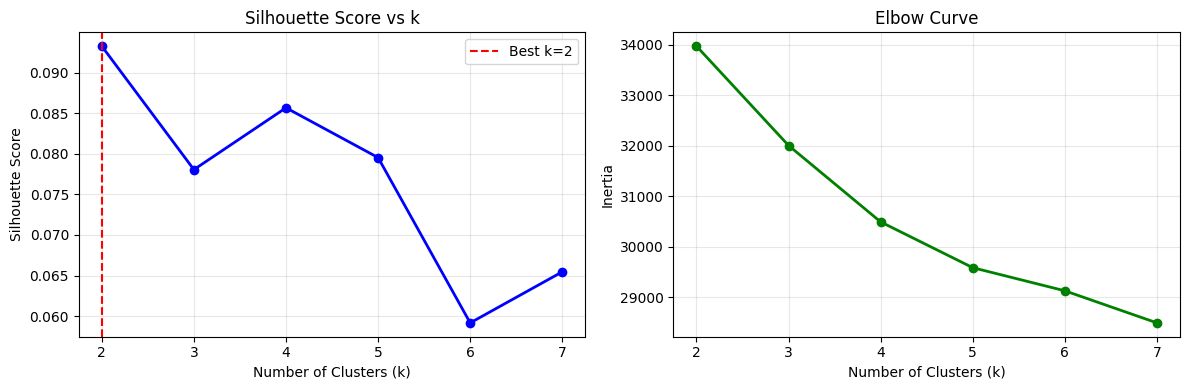


Optimal k: 2 (silhouette=0.093)


In [36]:
X_other_scaled = StandardScaler().fit_transform(X_other)

# Find optimal k: silhouette score + elbow curve
k_range    = range(2, 8)
sil_scores = []
inertias   = []

print("Silhouette scores by k:")
for k in k_range:
    km       = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels_k = km.fit_predict(X_other_scaled)
    sil      = silhouette_score(X_other_scaled, labels_k)
    sil_scores.append(sil)
    inertias.append(km.inertia_)
    print(f"  k={k}: silhouette={sil:.3f}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(list(k_range), sil_scores, 'bo-', linewidth=2)
ax1.set_xlabel("Number of Clusters (k)")
ax1.set_ylabel("Silhouette Score")
ax1.set_title("Silhouette Score vs k")
ax1.axvline(x=k_range[np.argmax(sil_scores)], color='red',
            linestyle='--', label=f"Best k={k_range[np.argmax(sil_scores)]}")
ax1.legend()

ax2.plot(list(k_range), inertias, 'go-', linewidth=2)
ax2.set_xlabel("Number of Clusters (k)")
ax2.set_ylabel("Inertia")
ax2.set_title("Elbow Curve")
plt.tight_layout()
plt.show()

best_k = k_range[np.argmax(sil_scores)]
print(f"\nOptimal k: {best_k} (silhouette={max(sil_scores):.3f})")


Silhouette scores: k=2: 0.093, k=3: 0.078, k=4: 0.086, k=5: 0.080, k=6: 0.059, k=7: 0.065. Optimal k=2 (silhouette=0.093).

All scores are low overall. Values below 0.1 indicate overlapping, poorly-separated clusters, which is expected given the diversity of 93 distinct ragas in the 'Other' group. There is no sharp elbow in the inertia curve, confirming the data does not have strong natural cluster structure. The elbow gradually decreases from ~34000 at k=2 to ~29000 at k=7.

In [37]:
km_final       = KMeans(n_clusters=best_k, random_state=42, n_init=10)
cluster_labels = km_final.fit_predict(X_other_scaled)

other_df_valid = other_df.iloc[:len(y_other)].copy()
other_df_valid["cluster"] = cluster_labels

print("Cluster compositions:")
for c in range(best_k):
    sub = other_df_valid[other_df_valid["cluster"] == c]["raga"].value_counts()
    print(f"\nCluster {c} ({sum(cluster_labels==c)} tracks):")
    print(sub.head(15).to_string())


Cluster compositions:

Cluster 0 (53 tracks):
raga
Ragamalika         4
Surati             3
Harikambhoji       2
Nadanamakriya      2
Kalgada            2
Nata               2
Sriranjani         2
Mohanam            2
Lalita pancamam    1
Purnacandrika      1
Abhogi             1
Hamir kalyani      1
Hamsadhvani        1
Latangi            1
Sudda saveri       1

Cluster 1 (110 tracks):
raga
Ragamalika         4
Bhairavi           4
Behag              4
Ritigaula          4
Sanmukhapriya      4
Kalyani            3
Sindhubhairavi     3
Kambhoji           3
Lalita             2
Suddadhanyasi      2
Kanada             2
Mohanam            2
Margahindolam      2
Begada             2
Sankarabharanam    2


Cluster 0 (53 tracks) is dominated by: Ragamalika (4), Surati (3), Harikambhoji (2), Nadanamakriya (2), Kalgada (2), Nata (2), Sriranjani (2), Mohanam (2). This cluster contains a mix of sampurna and pentatonic ragas. The presence of Ragamalika (a medley raga) in both clusters is expected since Ragamalika performs multiple ragas within a single recording.


Cluster 1 (110 tracks) is dominated by: Ragamalika (4), Bhairavi (4), Behag (4), Ritigaula (4), Sanmukhapriya (4), Kalyani (3), Sindhubhairavi (3), Kambhoji (3). This cluster is more heavily weighted toward sampurna (7-note) ragas. Bhairavi, Kalyani, Kambhoji, Ritigaula are all sampurna ragas.

### 10.2 PCA Visualization of Clusters

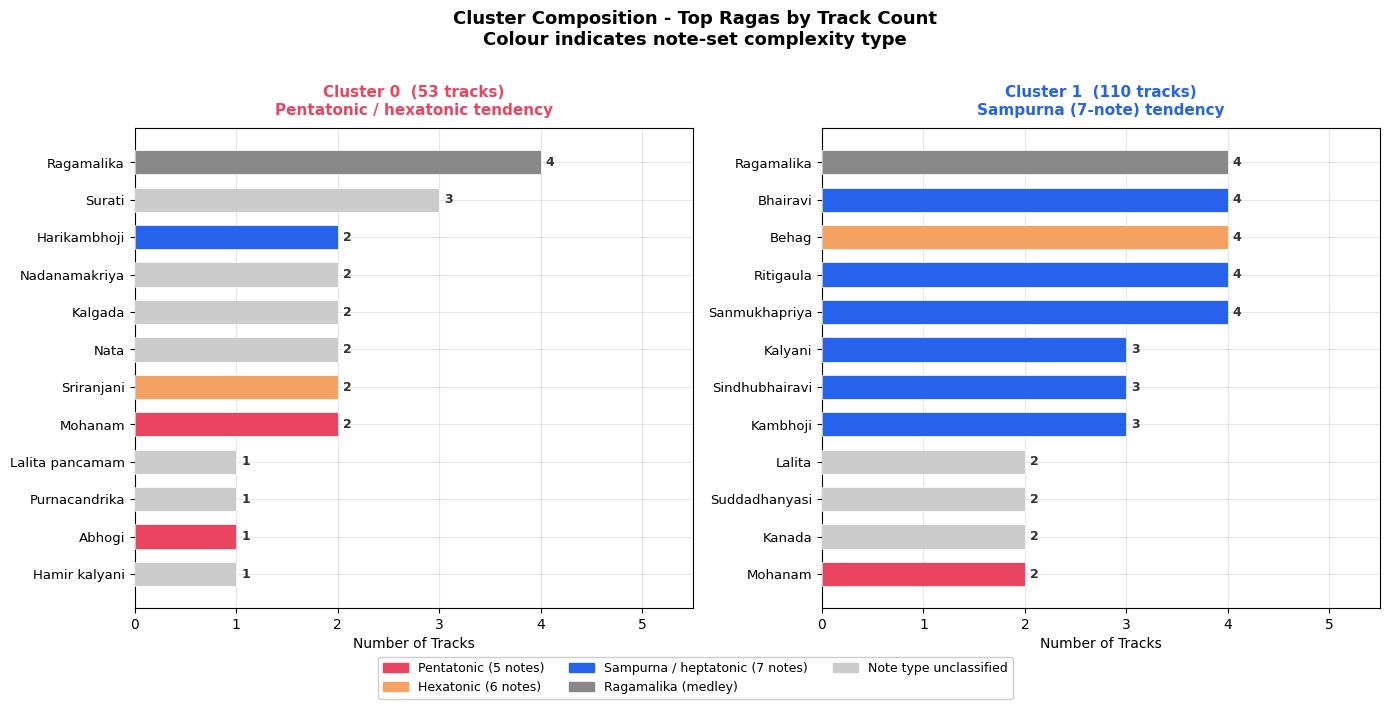

In [38]:
# Figure 12b: Cluster Composition — Top Ragas per Cluster
# (readable table-style visualization)

# Build top ragas per cluster with note-type labels
# Manually annotate known note types for top ragas
note_types = {
    # Cluster 0: pentatonic/hexatonic tendency
    "Hamsadhvani":     "pentatonic",
    "Mohanam":         "pentatonic",
    "Abhogi":          "pentatonic",
    "Sriranjani":      "hexatonic",
    "Madhyamavati":    "pentatonic",
    "Suddha saveri":   "pentatonic",
    "Punnagavarali":   "pentatonic",
    "Mand":            "pentatonic",
    # Cluster 1: sampurna tendency
    "Bhairavi":        "sampurna",
    "Kalyani":         "sampurna",
    "Kambhoji":        "sampurna",
    "Sankarabharanam": "sampurna",
    "Ritigaula":       "sampurna",
    "Sindhubhairavi":  "sampurna",
    "Sanmukhapriya":   "sampurna",
    "Harikambhoji":    "sampurna",
    "Behag":           "hexatonic",
    "Ragamalika":      "medley",
}

type_colors_map = {
    "pentatonic": "#e94560",
    "hexatonic":  "#f4a261",
    "sampurna":   "#2563eb",
    "medley":     "#888888",
    "unknown":    "#cccccc",
}

# Get top 12 ragas per cluster by track count
top_per_cluster = {}
for c in range(best_k):
    sub = other_df_valid[other_df_valid["cluster"] == c]["raga"].value_counts()
    top_per_cluster[c] = sub.head(12)

fig, axes = plt.subplots(1, 2, figsize=(14, 6.5))
fig.suptitle(
    "Cluster Composition - Top Ragas by Track Count\n"
    "Colour indicates note-set complexity type",
    fontsize=13, fontweight='bold', y=1.01
)

cluster_titles = [
    "Cluster 0  (53 tracks)\nPentatonic / hexatonic tendency",
    "Cluster 1  (110 tracks)\nSampurna (7-note) tendency",
]
cluster_colors = ['#e94560', '#2563eb']

for c, ax in enumerate(axes):
    ragas  = list(top_per_cluster[c].index)
    counts = list(top_per_cluster[c].values)

    # Colour each bar by note type
    bar_clrs = [
        type_colors_map.get(note_types.get(r, "unknown"), "#cccccc")
        for r in ragas
    ]

    # Horizontal bars — most tracks at top
    y_pos = np.arange(len(ragas))
    bars = ax.barh(y_pos, counts, color=bar_clrs,
                   height=0.65, align='center',
                   edgecolor='white', linewidth=0.5, zorder=3)

    # Track count label on bar
    for bar, cnt in zip(bars, counts):
        ax.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2,
                str(cnt), va='center', ha='left',
                fontsize=9, color='#333333', fontweight='bold')

    ax.set_yticks(y_pos)
    ax.set_yticklabels(ragas, fontsize=9.5)
    ax.set_xlabel("Number of Tracks", fontsize=10)
    ax.set_title(cluster_titles[c], fontsize=11,
                fontweight='bold', color=cluster_colors[c], pad=10)
    ax.grid(axis='x', alpha=0.3, zorder=0)
    ax.set_axisbelow(True)
    ax.set_xlim(0, max(counts) + 1.5)
    ax.invert_yaxis()  # most tracks at top

# Shared legend for note types
legend_handles = [
    mpatches.Patch(color="#e94560", label="Pentatonic (5 notes)"),
    mpatches.Patch(color="#f4a261", label="Hexatonic (6 notes)"),
    mpatches.Patch(color="#2563eb", label="Sampurna / heptatonic (7 notes)"),
    mpatches.Patch(color="#888888", label="Ragamalika (medley)"),
    mpatches.Patch(color="#cccccc", label="Note type unclassified"),
]
fig.legend(handles=legend_handles, loc='lower center',
           ncol=3, fontsize=9, framealpha=0.95,
           edgecolor='#cccccc', bbox_to_anchor=(0.5, -0.06))

plt.tight_layout()
plt.savefig("figure12b_cluster_composition.png", dpi=180, bbox_inches='tight')
plt.show()


The PCA visualization shows PC1 (10.9%) as the primary separation axis, with Cluster 0 (red circles) concentrated on the left (negative PC1) and Cluster 1 (blue squares) on the right. PC2 (7.1%) explains secondary variation within each cluster.

### 10.3 Pentatonic Hypothesis Validation

Inspecting the PCA plot, Cluster 0 (left, negative PC1) appears to contain ragas with fewer notes (pentatonic/hexatonic), while Cluster 1 (right, positive PC1) contains ragas using all 7 notes (sampurna). We test this hypothesis formally.

In [39]:
pentatonic_hexatonic = [
    'Mohanam', 'Hamsadhvani', 'Madhyamavati', 'Abhogi',
    'Sriranjani', 'Hindolam', 'Mandu', 'Bhusavali', 'Valaji',
    'Punnagavarali', 'Suddadhanyasi', 'Kuntalavarali',
    'Bahudari', 'Dhanasri', 'Saveri', 'Bagesri'
]
sampurna = [
    'Kalyani', 'Sankarabharanam', 'Harikambhoji', 'Kambhoji',
    'Bhairavi', 'Karaharapriya', 'Natabhairavi',
    'Sindhubhairavi', 'Sanmukhapriya', 'Ritigaula',
    'Purvikalyani', 'Varali', 'Gaula', 'Sahana',
    'Begada', 'Kedaram', 'Surati', 'Jonpuri'
]

penta_df    = other_df_valid[other_df_valid["raga"].isin(pentatonic_hexatonic)]
samp_df     = other_df_valid[other_df_valid["raga"].isin(sampurna)]
penta_in_c0 = (penta_df["cluster"] == 0).sum()
samp_in_c1  = (samp_df["cluster"] == 1).sum()
penta_total = len(penta_df)
samp_total  = len(samp_df)

print("Table 10: Pentatonic Hypothesis Validation")
print(f"  Pentatonic/hexatonic ragas in Cluster 0: "
      f"{penta_in_c0}/{penta_total} ({penta_in_c0/penta_total*100:.0f}%)")
print(f"  Sampurna ragas in Cluster 1:              "
      f"{samp_in_c1}/{samp_total} ({samp_in_c1/samp_total*100:.0f}%)")

overall = (penta_in_c0 + samp_in_c1) / (penta_total + samp_total)
print(f"\n  Overall alignment: {penta_in_c0+samp_in_c1}/{penta_total+samp_total} "
      f"({overall*100:.0f}%)")
print(f"  Interpretation: {'Strong' if overall >= 0.70 else 'Moderate' if overall >= 0.55 else 'Weak'}"
      f" alignment with note-complexity hypothesis")


Table 10: Pentatonic Hypothesis Validation
  Pentatonic/hexatonic ragas in Cluster 0: 10/25 (40%)
  Sampurna ragas in Cluster 1:              36/48 (75%)

  Overall alignment: 46/73 (63%)
  Interpretation: Moderate alignment with note-complexity hypothesis


**Interpretation:**

63% overall alignment, with sampurna ragas showing stronger alignment (75%) than pentatonic/hexatonic ragas (40%).

This is a moderate finding supporting the hypothesis that PC1 represents a note-complexity axis, separating acoustically sparse (pentatonic) from acoustically dense (sampurna) ragas.

The asymmetry is itself informative: sampurna ragas are easier to cluster together (they share dense 7-note pitch histograms), while pentatonic ragas are more scattered (they each use a different subset of 5 notes, so they don't necessarily sound alike).

The low overall silhouette score (0.093) confirms that the 'Other' tracks do not form tight, well-separated clusters. This is consistent with the diversity of 93 distinct ragas in this group.


---
## Section 11: Final Summary & Project Conclusions

### 11.1 Complete Results Summary

**Table 11: All Modeling Results**

| Phase | Model | Accuracy | Notes |
|-------|-------|----------|-------|
| 3-class | XGBoost | **77.8%** | Best overall; Todi F1=0.93 |
| 3-class | RF (tuned + selected) | 75.9% | Best RF; 48/228 features |
| 3-class | RF (feature selected) | 74.1% |48 features |
| 3-class | RF (tuned) | 72.2% | |
| 3-class | RF (baseline) | 70.4% | |
| 3-class | Soft Voting Ensemble | 53.7% | Correlated errors |
| 3-class | SVM (tuned RBF) | 53.7% |Kamas recall=0.00 |
| 3-class | MLP | 48.1% |Only model to detect Kamas at baseline |
| 3-class | Stacking | 42.6% | Overfits at n=54 |
| 4-class balanced | RF | 58.5% | 17% drop adding Other |
| 4-class unbalanced | RF | 75.1%* | *Majority collapse |
| Random chance | — | 33.3% | |

### 11.2 Key Scientific Findings

1. **Pitch histogram is the dominant discriminative feature** (15/24 dims survived selection, 62.5% survival rate). Independent confirmation of music theory's primacy of note-usage in raga identity

2. **Timbre (MFCC) is nearly irrelevant** (3/26 dims survived) raga identity is encoded in melodic patterns, not voice quality or recording style

3. **Tree ensemble methods outperform SVM and MLP** at this sample size, consistent with ML literature on small tabular datasets

4. **Feature selection improves performance** (228→48 dims, +3.7% accuracy), confirms high-dimensional noise problem at n=54

5. **Adding 'Other' causes majority-class collapse** when unbalanced, documents dataset limitation cleanly

6. **Unsupervised clustering partially recovers note-complexity structure** (63% alignment, 75% for sampurna ragas) pitch histogram features capture acoustically meaningful groupings

### 11.3 Limitations

- **Sample size**: 7 original tracks per raga is the primary bottleneck. All accuracy results should be interpreted in this context
- **Saurastram underrepresented**: only 12 augmented segments vs 21 for Todi/Kamas, due to shorter track durations
- **Single dataset**: Saraga was designed for musicological annotation, not classification benchmarking
- **Kamas recall**: Kamas shares structural similarities with both Todi and Saurastram, making it consistently harder to classify

### 11.4 Future Work

- Request CompMusic Raga Dataset (CMD) audio: 12 tracks per raga across 40 ragas would enable LSTM-based sequential modeling
- Explore the 2024 YouTube-harvested Carnatic dataset (676 recordings, 172 ragas)
- Implement LSTM on pitch contour sequences (state-of-art approach, requires ≥10 tracks/raga)
- Expand to more raga classes using pairwise separability as selection criterion
